In [1]:
# start here

In [2]:

# plot_size = [15,10]

In [3]:
# plot_regime_map_smooth(dfT)

In [4]:
# for Tm in sorted(dfT["T_m"].dropna().unique()):
#     sub = dfT[dfT["T_m"] == Tm]
#     print("\nT_m =", Tm)
#     print(sub[["omega", "Ri_crit", "xi_crit", "regime", "n_candidates"]].to_string(index=False))

In [5]:
# Tm_vals_K = np.array([700, 900, 1100]) + 273.15
# omega_vals = np.linspace(0.0, 0.60, 61)
# df_analytic = sweep_temperature_and_omega(Tm_vals_K, omega_vals, default_params())
# df_analytic["T_C"] = df_analytic["T_m"] - 273.15

In [6]:
# Tm_vals_K = np.array([700, 900, 1100]) + 273.15
# omega_vals = np.linspace(0.0, 0.60, 61)

# p = default_params()
# df_analytic = sweep_temperature_and_omega(Tm_vals_K, omega_vals, p)
# df_analytic["T_C"] = df_analytic["T_m"] - 273.15

In [7]:
# def plot_Ri_vs_omega_by_regime(dfT):
#     colors = {"A": "#0072B2", "B": "#E69F00", "C": "#009E73"}
#     markers = {"A": "o", "B": "s", "C": "^"}

#     plt.figure(figsize=(8, 6))

#     # plot the common regimes first
#     for reg in ["A", "C"]:
#         sub = dfT[dfT["regime"] == reg].dropna(subset=["Ri_crit", "omega"])
#         if sub.empty:
#             continue

#         plt.scatter(
#             sub["Ri_crit"],
#             sub["omega"],
#             c=colors[reg],
#             marker=markers[reg],
#             s=35,
#             edgecolors="black",
#             linewidths=0.4,
#             alpha=0.75,
#             label=f"Regime {reg}",
#             zorder=2,
#         )

#     # plot Regime B last, larger, with strong outline
#     subB = dfT[dfT["regime"] == "B"].dropna(subset=["Ri_crit", "omega"])
#     if not subB.empty:
#         # optional white halo underneath
#         plt.scatter(
#             subB["Ri_crit"],
#             subB["omega"],
#             c="white",
#             marker=markers["B"],
#             s=120,
#             edgecolors="black",
#             linewidths=1.0,
#             alpha=1.0,
#             zorder=4,
#         )

#         plt.scatter(
#             subB["Ri_crit"],
#             subB["omega"],
#             c=colors["B"],
#             marker=markers["B"],
#             s=70,
#             edgecolors="black",
#             linewidths=0.9,
#             alpha=1.0,
#             label="Regime B",
#             zorder=5,
#         )

#     plt.xscale("log")
#     plt.xlabel(r"$Ri_{\mathrm{crit}}$")
#     plt.ylabel(r"$w$")
#     plt.legend(frameon=False)
#     plt.tight_layout()
#     plt.show()

In [8]:
# plot_Ri_vs_omega_by_regime(dfT)

In [9]:
# print(dfT["regime"].value_counts(dropna=False))

In [10]:
# print(pd.crosstab(dfT["T_m"], dfT["regime"]))

In [11]:
# def plot_analytic_clusters_by_regime(dfT):
#     colors = {"A": "#0072B2", "B": "#E69F00", "C": "#009E73"}
#     markers = {"A": "o", "B": "s", "C": "^"}

#     plt.figure(figsize=(8, 6))

#     for reg in ["A", "B", "C"]:
#         sub = dfT[dfT["regime"] == reg].dropna(subset=["Ri_crit", "omega"])
#         if sub.empty:
#             continue

#         plt.scatter(
#             sub["Ri_crit"],
#             sub["omega"],
#             color=colors[reg],
#             marker=markers[reg],
#             s=40,
#             edgecolors="black",
#             linewidths=0.4,
#             alpha=0.9,
#             label=f"Analytic Regime {reg}",
#         )

#     plt.xscale("log")
#     plt.xlabel(r"$Ri_{\mathrm{crit}}$")
#     plt.ylabel(r"$w$")
#     plt.legend(frameon=True)
#     plt.tight_layout()
#     plt.show()

In [12]:
# print(dfT["regime"].value_counts(dropna=False))
# print(pd.crosstab(dfT["T_m"], dfT["regime"]))
# plot_Ri_vs_omega_by_regime(dfT)

In [65]:
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ============================================================
# SWEEP WITH CELSIUS + NONDIMENSIONAL TEMPERATURE
# ============================================================

def sweep_temperature_and_omega(Tm_values, omega_values, base_params):
    rows = []

    for Tm in Tm_values:
        pT = dict(base_params)
        pT["T_m"] = float(Tm)

        prev_xi = None

        for omega in omega_values:
            p = dict(pT)
            p["omega"] = float(omega)

            out = compute_state_liquid(p, previous_xi=prev_xi)

            rows.append({
                "T_m": Tm,
                "T_m_C": Tm - 273.15,
                "theta_m": Tm / p["T_sat"],
                "omega": omega,
                "xi_crit": out["xi_crit"],
                "Ri_crit": out["Ri_crit"],
                "regime": out["regime"],
                "n_candidates": len(out["candidates"]),
            })

            if np.isfinite(out["xi_crit"]):
                prev_xi = out["xi_crit"]

    return pd.DataFrame(rows)


# ============================================================
# CATEGORICAL REGIME MAP HELPERS
# ============================================================

def _centers_to_edges(vals):
    vals = np.asarray(vals, dtype=float)

    if vals.size == 1:
        d = 0.5
        return np.array([vals[0] - d, vals[0] + d])

    mids = 0.5 * (vals[:-1] + vals[1:])
    first = vals[0] - 0.5 * (vals[1] - vals[0])
    last = vals[-1] + 0.5 * (vals[-1] - vals[-2])

    return np.concatenate([[first], mids, [last]])


def _regime_style():
    regime_to_num = {
        "no_root": -1,
        "A": 0,
        "B": 1,
        "C": 2,
    }

    regime_colors = {
        "no_root": "#E6E6E6",  # light gray
        "A": "#6B7C8F",        # blue-gray
        "B": "#A0836B",        # warm gray-brown
        "C": "#7A8A72",        # sage gray-green
    }

    regime_labels = {
        "no_root": "No valid threshold",
        "A": "A: Sub-boiling liquid water",
        "B": "B: Partial vaporization",
        "C": "C: Complete vaporization",
    }

    cmap = ListedColormap([
        regime_colors["no_root"],
        regime_colors["A"],
        regime_colors["B"],
        regime_colors["C"],
    ])

    levels = [-1.5, -0.5, 0.5, 1.5, 2.5]
    norm = BoundaryNorm(levels, cmap.N)

    return regime_to_num, regime_colors, regime_labels, cmap, norm


def _prepare_regime_grid(dfT, x_col):
    regime_to_num, regime_colors, regime_labels, cmap, norm = _regime_style()

    dfp = dfT.copy()

    dfp["regime_plot"] = (
        dfp["regime"]
        .fillna("no_root")
        .astype(str)
        .str.strip()
    )

    dfp["regime_num"] = dfp["regime_plot"].map(regime_to_num)
    dfp["regime_num"] = dfp["regime_num"].fillna(regime_to_num["no_root"])

    grid = dfp.pivot_table(
        index="omega",
        columns=x_col,
        values="regime_num",
        aggfunc="first"
    ).sort_index().sort_index(axis=1)

    y_vals = grid.index.to_numpy(dtype=float)
    x_vals = grid.columns.to_numpy(dtype=float)
    Z = grid.to_numpy(dtype=float)

    x_edges = _centers_to_edges(x_vals)
    y_edges = _centers_to_edges(y_vals)

    return dfp, x_edges, y_edges, Z, regime_colors, regime_labels, cmap, norm


def _add_regime_legend(ax, dfp, regime_colors, regime_labels):
    present_regimes = [
        reg for reg in ["no_root", "A", "B", "C"]
        if reg in set(dfp["regime_plot"].dropna().unique())
    ]

    legend_handles = [
        mpatches.Patch(
            color=regime_colors[reg],
            label=regime_labels[reg]
        )
        for reg in present_regimes
    ]

    leg = ax.legend(
        handles=legend_handles,
        frameon=True,
        loc="upper right",
        fontsize=14,
        framealpha=0.9,
        edgecolor="black",
        fancybox=False,
        borderpad=0.4,
        labelspacing=0.4,
        handlelength=1.6
    )

    leg.get_frame().set_facecolor("white")
    leg.get_frame().set_linewidth(1.0)


# ============================================================
# NONDIMENSIONAL REGIME MAP
# ============================================================

def plot_regime_map_theta(dfT):
    dfp = dfT.copy()

    if "theta_m" not in dfp.columns:
        dfp["theta_m"] = dfp["T_m"] / 373.15

    dfp, x_edges, y_edges, Z, regime_colors, regime_labels, cmap, norm = (
        _prepare_regime_grid(dfp, "theta_m")
    )

    fig, ax = plt.subplots(figsize=(6, 8), constrained_layout=True)

    ax.pcolormesh(
        x_edges,
        y_edges,
        Z,
        cmap=cmap,
        norm=norm,
        shading="flat",
        edgecolors="none"
    )

    ax.set_xlabel(r"$\theta = T_m/T_{\mathrm{sat}}$", fontsize=18, labelpad=10)
    ax.set_ylabel(r"$\omega$", fontsize=18, labelpad=12)

    ax.tick_params(axis="both", which="major", labelsize=18, pad=6)

    _add_regime_legend(ax, dfp, regime_colors, regime_labels)

    fig.savefig(
        "regime_map_theta_w.png",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.15
    )

    fig.savefig(
        "regime_map_theta_w.pdf",
        bbox_inches="tight",
        pad_inches=0.15
    )

    plt.show()


# ============================================================
# CELSIUS REGIME MAP
# ============================================================

def plot_regime_map_celsius(dfT):
    dfp = dfT.copy()

    if "T_m_C" not in dfp.columns:
        dfp["T_m_C"] = dfp["T_m"] - 273.15

    dfp, x_edges, y_edges, Z, regime_colors, regime_labels, cmap, norm = (
        _prepare_regime_grid(dfp, "T_m_C")
    )

    fig, ax = plt.subplots(figsize=(6, 8), constrained_layout=True)

    ax.pcolormesh(
        x_edges,
        y_edges,
        Z,
        cmap=cmap,
        norm=norm,
        shading="flat",
        edgecolors="none"
    )

    ax.set_xlabel(r"$T_m$ [$^\circ$C]", fontsize=18, labelpad=10)
    ax.set_ylabel(r"$\omega$", fontsize=18, labelpad=12)

    ax.tick_params(axis="both", which="major", labelsize=18, pad=6)

    _add_regime_legend(ax, dfp, regime_colors, regime_labels)

    fig.savefig(
        "regime_map_Tm_w_B.png",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.15
    )

    fig.savefig(
        "regime_map_Tm_w_B.pdf",
        bbox_inches="tight",
        pad_inches=0.15
    )

    plt.show()


# ============================================================
# MAIN CALL
# ============================================================

if __name__ == "__main__":
    p = default_params()

    omega_vals = np.linspace(0.0, 0.60, 61)

    Tm_vals_C = np.linspace(300.0, 1500.0, 301)
    Tm_vals = Tm_vals_C + 273.15

    dfT = sweep_temperature_and_omega(Tm_vals, omega_vals, p)

    dfT.to_csv("xi_crit_temp_omega_sweep_with_theta.csv", index=False)

    print(dfT["regime"].fillna("no_root").value_counts())

    plot_regime_map_theta(dfT)
    plot_regime_map_celsius(dfT)

NameError: name 'default_params' is not defined

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def collect_xi_branch_data(Tm, omega_values, base_params):
    rows = []
    prev_xi = None

    for omega in omega_values:
        p = dict(base_params)
        p["T_m"] = float(Tm)
        p["omega"] = float(omega)

        out = compute_state_liquid(p, previous_xi=prev_xi)

        # selected root
        rows.append({
            "omega": omega,
            "xi": out["xi_crit"],
            "regime": out["regime"],
            "kind": "selected",
        })

        # all admissible candidates
        for reg, xi in out["candidates"]:
            rows.append({
                "omega": omega,
                "xi": xi,
                "regime": reg,
                "kind": "candidate",
            })

        if np.isfinite(out["xi_crit"]):
            prev_xi = out["xi_crit"]

    return pd.DataFrame(rows)


def plot_xi_branches(Tm, omega_values, base_params):
    df = collect_xi_branch_data(Tm, omega_values, base_params)

    colors = {
        "A": "#1f77b4",
        "B": "#ff7f0e",
        "C": "#2ca02c",
    }

    fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

    # plot all admissible candidates as open markers
    cand = df[df["kind"] == "candidate"]
    for reg in ["A", "B", "C"]:
        sub = cand[cand["regime"] == reg]
        if len(sub) == 0:
            continue
        ax.scatter(
            sub["omega"],
            sub["xi"],
            s=55,
            facecolors="none",
            edgecolors=colors[reg],
            linewidths=1.2,
            alpha=0.9,
            label=f"{reg} candidate"
        )

    # plot selected root as filled markers + line
    sel = df[df["kind"] == "selected"].copy()

    # line through selected roots; NaNs automatically create gaps
    ax.plot(
        sel["omega"],
        sel["xi"],
        color="0.25",
        linewidth=1.6,
        alpha=0.8,
        zorder=1
    )

    for reg in ["A", "B", "C"]:
        sub = sel[sel["regime"] == reg]
        if len(sub) == 0:
            continue
        ax.scatter(
            sub["omega"],
            sub["xi"],
            s=70,
            color=colors[reg],
            edgecolors="black",
            linewidths=0.5,
            zorder=3,
            label=f"Selected {reg}"
        )

    ax.set_xlabel(r"$w$")
    ax.set_ylabel(r"$\xi_{\mathrm{crit}}$")
    ax.set_title(fr"$T_m = {Tm:.0f}\ \mathrm{{K}}$")
    ax.set_ylim(0, 1)
    ax.legend(frameon=True, fontsize=10, ncol=2)

    fig.savefig(
        "diagnostic.png",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.15
    )


    plt.show()

In [55]:
p = default_params()
omega_vals = np.linspace(0.0, 0.60, 71)

plot_xi_branches(800.0, omega_vals, p)     # if T_m is actually 800 K
# or
plot_xi_branches(1073.15, omega_vals, p)   # if you mean 800 °C

NameError: name 'default_params' is not defined

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl


# ============================================================
# Residual functions
# ============================================================

def P_C(xi, p):
    aC, bC, cC = regime_C_coeffs(p)
    return aC * xi**2 + bC * xi + cC


def P_A(xi, p):
    aA, bA, cA = regime_A_coeffs(p)
    return aA * xi**2 + bA * xi + cA


# ============================================================
# Combined Regime C + Regime A residual diagnostic
# ============================================================

def plot_regime_residuals_combined(Tm, omega_list_C, omega_list_A, base_params):
    fig, axes = plt.subplots(
        2, 1,
        figsize=(8, 10),
        sharex=True,
        constrained_layout=True
    )

    axC, axA = axes

    # -----------------------------
    # Regime C residuals
    # -----------------------------
    cmap_C = plt.cm.cividis
    norm_C = mpl.colors.Normalize(vmin=min(omega_list_C), vmax=max(omega_list_C))

    for omega in omega_list_C:
        p = dict(base_params)
        p["T_m"] = float(Tm)
        p["omega"] = float(omega)
        compute_derived(p)

        xi_max = 1.0 - omega
        xi_vals = np.linspace(0.0, xi_max, 600)
        F_vals = np.array([P_C(xi, p) for xi in xi_vals])

        color = cmap_C(norm_C(omega))

        axC.plot(
            xi_vals,
            F_vals,
            color=color,
            linewidth=2.0,
            label=fr"$w={omega:.2f}$"
        )

        roots = quadratic_roots(*regime_C_coeffs(p))

        for root in roots:
            if valid_regime_C(root, p):
                axC.scatter(
                    root,
                    0.0,
                    s=55,
                    color=color,
                    edgecolors="black",
                    linewidths=0.8,
                    zorder=5
                )

    axC.axhline(0.0, color="black", linewidth=1.0)
    axC.set_ylabel("Regime C residual")
    axC.legend(frameon=False, title=r"$w$", ncol=2)
    axC.text(
        0.02, 0.95, "(a)",
        transform=axC.transAxes,
        ha="left",
        va="top",
        fontsize=16
    )

    # -----------------------------
    # Regime A residuals
    # -----------------------------
    cmap_A = plt.cm.cividis_r
    norm_A = mpl.colors.Normalize(vmin=min(omega_list_A), vmax=max(omega_list_A))

    xi_grid = np.linspace(0.0, 1.0, 600)

    for omega in omega_list_A:
        p = dict(base_params)
        p["T_m"] = float(Tm)
        p["omega"] = float(omega)
        compute_derived(p)

        xi_max = 1.0 - omega
        xi_vals = xi_grid[xi_grid <= xi_max]
        F_vals = np.array([P_A(xi, p) for xi in xi_vals])

        color = cmap_A(norm_A(omega))

        axA.plot(
            xi_vals,
            F_vals,
            color=color,
            linewidth=2.0,
            label=fr"$w={omega:.2f}$"
        )

        roots = quadratic_roots(*regime_A_coeffs(p))

        for root in roots:
            if valid_regime_A(root, p):
                axA.scatter(
                    root,
                    0.0,
                    s=55,
                    color=color,
                    edgecolors="black",
                    linewidths=0.8,
                    zorder=5
                )

    axA.axhline(0.0, color="black", linewidth=1.0)
    axA.set_xlabel(r"$\xi$")
    axA.set_ylabel("Regime A residual")
    axA.legend(frameon=False, title=r"$w$", ncol=2)
    axA.text(
        0.02, 0.95, "(b)",
        transform=axA.transAxes,
        ha="left",
        va="top",
        fontsize=16
    )

    fig.savefig(
        "regime_residual_diagnostics.png",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.15
    )

    fig.savefig(
        "regime_residual_diagnostics.pdf",
        bbox_inches="tight",
        pad_inches=0.15
    )

    plt.show()


# ============================================================
# Run diagnostic
# ============================================================

p = default_params()

Tm_plot = 800.0 + 273.15  # 800 C in Kelvin

plot_regime_residuals_combined(
    Tm=Tm_plot,
    omega_list_C=[0.00, 0.10, 0.15, 0.18, 0.37, 0.39, 0.40],
    omega_list_A=[0.16, 0.18, 0.20, 0.22, 0.24],
    base_params=p
)

NameError: name 'default_params' is not defined

In [57]:
from matplotlib import cm, colors
import numpy as np
import matplotlib.pyplot as plt


def plot_Ri_vs_omega_by_temperature_viridis_markers(
    dfT,
    Tm_requested=(600, 700, 800, 900, 1000, 1100, 1200),
    savepath="ri_v_omega_viridis_markers.png",
):
    fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

    dfp = dfT.copy()

    # Force numeric columns
    dfp["T_m_C"] = np.asarray(dfp["T_m_C"], dtype=float)
    dfp["Ri_crit"] = np.asarray(dfp["Ri_crit"], dtype=float)
    dfp["omega"] = np.asarray(dfp["omega"], dtype=float)

    # Drop rows that cannot be plotted on a log Ri axis
    dfp = dfp.dropna(subset=["T_m_C", "Ri_crit", "omega"])
    dfp = dfp[dfp["Ri_crit"] > 0]

    if dfp.empty:
        raise ValueError("No valid rows with finite omega and positive Ri_crit.")

    Tm_requested = np.asarray(Tm_requested, dtype=float)

    # Keep requested temperatures that exist in the data, using tolerance
    Tm_plot = []
    for T in Tm_requested:
        if np.any(np.isclose(dfp["T_m_C"], T, atol=1e-6)):
            Tm_plot.append(T)

    Tm_plot = np.asarray(Tm_plot, dtype=float)

    if Tm_plot.size == 0:
        raise ValueError("None of the requested T_m values are present in dfT.")

    cmap = cm.viridis

    # Avoid bad normalization if only one temperature is plotted
    if Tm_plot.size == 1:
        norm = colors.Normalize(vmin=Tm_plot[0] - 1.0, vmax=Tm_plot[0] + 1.0)
    else:
        norm = colors.Normalize(vmin=Tm_plot.min(), vmax=Tm_plot.max())

    marker_list = ["o", "s", "^", "D", "v", "P", "X"]

    for i, Tm_C in enumerate(Tm_plot):
        sub = dfp[np.isclose(dfp["T_m_C"], Tm_C, atol=1e-6)].copy()
        sub = sub.sort_values("omega")

        if sub.empty:
            continue

        ax.scatter(
            sub["Ri_crit"],
            sub["omega"],
            marker=marker_list[i % len(marker_list)],
            s=45,
            color=cmap(norm(Tm_C)),
            edgecolors="black",
            linewidths=0.4,
            alpha=0.95,
            label=fr"$T_m = {Tm_C:.0f}^\circ\mathrm{{C}}$",
            zorder=3,
        )

    ax.set_xscale("log")

    ax.set_xlabel(r"$Ri_{\mathrm{crit}}$", fontsize=18, labelpad=10)
    ax.set_ylabel(r"$\omega$", fontsize=18, labelpad=12)
    ax.tick_params(axis="both", which="major", labelsize=16, pad=6)
    ax.tick_params(axis="both", which="minor", labelsize=14)

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label(r"$T_m$ [$^\circ$C]", fontsize=16)
    cbar.ax.tick_params(labelsize=14)
    cbar.set_ticks(Tm_plot)
    cbar.set_ticklabels([f"{T:.0f}" for T in Tm_plot])

    ax.legend(loc="best", frameon=True, fontsize=11)

    fig.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.show()

In [51]:
print(np.sort(dfT["T_m_C"].round(6).unique()))
print(len(dfT["T_m_C"].round(6).unique()))

NameError: name 'dfT' is not defined

In [ ]:
plot_Ri_vs_omega_by_temperature_viridis_markers(dfT)

In [59]:
def collect_eta_candidates(Tm, omega_values, base_params):
    rows = []

    for omega in omega_values:
        if omega == 0:
            continue

        p = dict(base_params)
        p["T_m"] = float(Tm)
        p["omega"] = float(omega)
        compute_derived(p)

        # A candidates
        for root in quadratic_roots(*regime_A_coeffs(p)):
            if 0 <= root <= 1 - omega:
                rows.append({
                    "omega": omega,
                    "xi": root,
                    "regime_eq": "A",
                    "eta": H_i(root, p) / (omega * p["L_v"]),
                    "valid": valid_regime_A(root, p),
                })

        # B candidate
        xiB = regime_B_root(p)  # use whatever your function is called
        if np.isfinite(xiB) and 0 <= xiB <= 1 - omega:
            rows.append({
                "omega": omega,
                "xi": xiB,
                "regime_eq": "B",
                "eta": H_i(xiB, p) / (omega * p["L_v"]),
                "valid": valid_regime_B(xiB, p),
            })

        # C candidates
        for root in quadratic_roots(*regime_C_coeffs(p)):
            if 0 <= root <= 1 - omega:
                rows.append({
                    "omega": omega,
                    "xi": root,
                    "regime_eq": "C",
                    "eta": H_i(root, p) / (omega * p["L_v"]),
                    "valid": valid_regime_C(root, p),
                })

    return pd.DataFrame(rows)

In [61]:
def collect_eta_candidates(Tm, omega_values, base_params):
    rows = []

    for omega in omega_values:
        if omega <= 0:
            continue

        p = dict(base_params)
        p["T_m"] = float(Tm)
        p["omega"] = float(omega)
        compute_derived(p)

        omegaLv = p["omega"] * p["L_v"]

        # Regime A candidates
        for xi in quadratic_roots(*regime_A_coeffs(p)):
            if in_bounds(xi, p["omega"]):
                eta = H_i(xi, p) / omegaLv
                rows.append({
                    "omega": omega,
                    "xi": xi,
                    "regime_eq": "A",
                    "eta": eta,
                    "valid": valid_regime_A(xi, p),
                })

        # Regime B candidate
        xiB = xi_crit_B(p)
        if np.isfinite(xiB) and in_bounds(xiB, p["omega"]):
            eta = H_i(xiB, p) / omegaLv
            rows.append({
                "omega": omega,
                "xi": xiB,
                "regime_eq": "B",
                "eta": eta,
                "valid": valid_regime_B(xiB, p),
            })

        # Regime C candidates
        for xi in quadratic_roots(*regime_C_coeffs(p)):
            if in_bounds(xi, p["omega"]):
                eta = H_i(xi, p) / omegaLv
                rows.append({
                    "omega": omega,
                    "xi": xi,
                    "regime_eq": "C",
                    "eta": eta,
                    "valid": valid_regime_C(xi, p),
                })

    return pd.DataFrame(rows)


def plot_eta_candidates(df_eta):
    fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

    # Regime B window
    ax.axhspan(0, 1, color="0.9", zorder=0, label=r"Regime B interval")
    ax.axhline(0, color="black", linewidth=1.0)
    ax.axhline(1, color="black", linewidth=1.0)

    colors = {
        "A": "#6B7C8F",
        "B": "#A0836B",
        "C": "#7A8A72",
    }

    for reg in ["A", "B", "C"]:
        sub = df_eta[df_eta["regime_eq"] == reg]
        if sub.empty:
            continue

        valid = sub[sub["valid"]]
        invalid = sub[~sub["valid"]]

        # invalid/inadmissible candidates: open markers
        ax.scatter(
            invalid["omega"],
            invalid["eta"],
            s=45,
            facecolors="none",
            edgecolors=colors[reg],
            linewidths=1.0,
            alpha=0.7,
            label=fr"Regime {reg} candidate",
        )

        # valid candidates: filled markers
        ax.scatter(
            valid["omega"],
            valid["eta"],
            s=50,
            color=colors[reg],
            edgecolors="black",
            linewidths=0.6,
            alpha=0.95,
            label=fr"Valid Regime {reg}",
        )

    ax.set_xlabel(r"$w$")
    ax.set_ylabel(r"$\eta = H_i(\xi_j)/(wL_v)$")

    ax.set_ylim(-0.5, 2.0)
    ax.legend(frameon=False, fontsize=9, ncol=2)

    fig.savefig(
        "eta_candidate_diagnostic.png",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.15
    )

    fig.savefig(
        "eta_candidate_diagnostic.pdf",
        bbox_inches="tight",
        pad_inches=0.15
    )

    plt.show()

In [63]:
omega_eta = np.linspace(0.001, 0.60, 150)

df_eta = collect_eta_candidates(
    Tm=300.0 + 273.15,
    omega_values=omega_eta,
    base_params=p
)

df_eta.to_csv("eta_candidate_diagnostic.csv", index=False)

plot_eta_candidates(df_eta)

NameError: name 'p' is not defined

In [ ]:
# plot_regime_map_smooth(dfT)

# start here
---



LIQUID + PHASE CHANGE, OMEGA PARAMETERIZATION
{'xi_crit': np.float64(0.782482590499596), 'Ri_crit': np.float64(0.3597333161960734), 'Omega': 0.05, 'omega_eff': np.float64(0.0391241295249798), 'Y_air_crit': np.float64(0.1783932799754242), 'regime': 'C', 'candidates': [('C', np.float64(0.782482590499596))], 'case': 'liquid_phase_change_Omega'}

OMEGA SWEEP
 Omega  omega_eff  Y_air_crit  xi_crit  Ri_crit regime  n_candidates
 0.000   0.000000    0.229272 0.770728 0.336163    dry             0
 0.001   0.000771    0.228263 0.770966 0.336617      C             1
 0.002   0.001542    0.227253 0.771205 0.337072      C             1
 0.003   0.002314    0.226243 0.771443 0.337527      C             1
 0.004   0.003087    0.225232 0.771681 0.337984      C             1
 0.005   0.003860    0.224221 0.771919 0.338441      C             1
 0.006   0.004633    0.223210 0.772157 0.338898      C             1
 0.007   0.005407    0.222199 0.772395 0.339357      C             1
 0.008   0.006181    

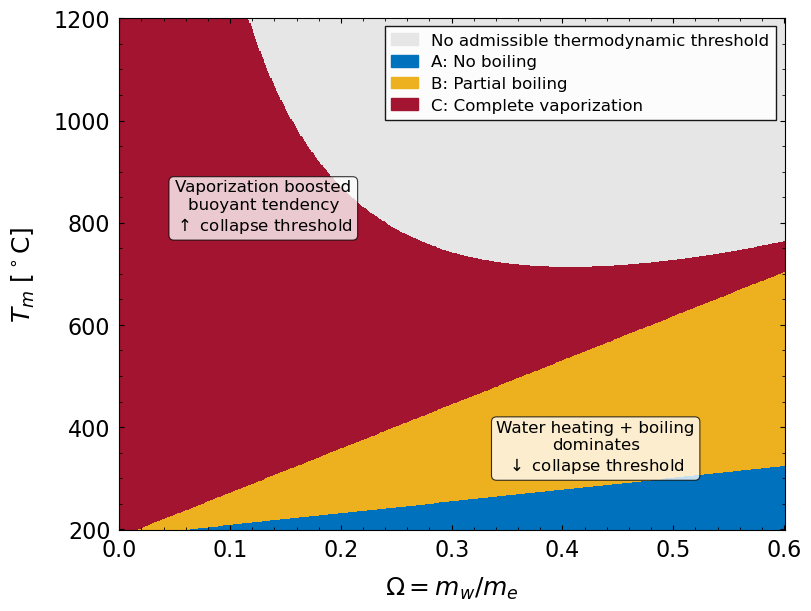

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

# ============================================================
# DEFAULT PARAMETERS
# ============================================================

params = {
    'legend.title_fontsize': 'large',
    'axes.labelsize': 16,
    'font.size': 14,
    'legend.fontsize': 12,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'text.usetex': False,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.top': True,
    'ytick.right': True,
    'figure.autolayout': True,
}
plt.rcParams.update(params)


def default_params():
    return {
        # control parameters
        "Omega": 0.05,          # external water loading, m_w / m_erupted
        "n": 0.03,              # volcanic gas fraction in erupted material

        # temperatures [K]
        "T_m": 1100.0,
        "T_air": 273.15,
        "T_w0": 273.15,         # external liquid water temperature
        "T_sat": 373.15,        # saturation temperature

        # heat capacities [J/kg/K]
        "Cp_air": 1004.0,
        "Cp_m": 3000.0,
        "Cp_w": 1850.0,         # water vapor
        "Cp_l": 4180.0,         # liquid water

        # gas constants [J/kg/K]
        "R_air": 287.0,
        "R_g": 461.5,           # volcanic gas
        "R_w": 461.5,           # water vapor

        # latent heat [J/kg]
        "L_v": 2.5e6,

        # constants for Ri(xi)
        "C": 2.0,
        "k": 0.05,
        "rho_air": 1.2,
        "rho_a": 1.2,

        # optional plume-state parameters
        "g": 9.81,
        "u0": 100.0,
        "D": 50.0,

        "Y_air_min": 1e-10,          # minimum entrained-air mass fraction allowed
    }


# ============================================================
# BASIC HELPERS
# ============================================================

def quadratic_roots(a, b, c, tol=1e-14):
    if abs(a) < tol:
        if abs(b) < tol:
            return []
        return [-c / b]

    disc = b * b - 4.0 * a * c
    if disc < -tol:
        return []
    if abs(disc) <= tol:
        return [-b / (2.0 * a)]

    s = np.sqrt(max(disc, 0.0))
    return [(-b + s) / (2.0 * a), (-b - s) / (2.0 * a)]


def xi_max_from_Omega(p):
    return 1.0 / (1.0 + p["Omega"])


def fractions_from_xi(xi, p):
    omega = p["Omega"] * xi
    Y_air = 1.0 - xi - omega
    return omega, Y_air


def in_bounds_Omega(xi, p, tol=1e-12):
    return (-tol <= xi <= xi_max_from_Omega(p) + tol)

def valid_air_fraction_Omega(xi, p):
    _, Y_air = fractions_from_xi(xi, p)
    return Y_air > p.get("Y_air_min", 0.0)


# ============================================================
# DRY ROOT
# ============================================================

def xi_crit_dry(p):
    R_air = p["R_air"]
    Cp_m = p["Cp_m"]
    Cp_air = p["Cp_air"]
    T_m = p["T_m"]
    T_air = p["T_air"]
    n = p["n"]
    R_g = p["R_g"]

    num = (
        R_air * Cp_m * (T_m - T_air)
        - Cp_air * T_air * (R_air - n * R_g)
    )
    den = (
        (R_air - n * R_g)
        * (Cp_m * T_m - Cp_air * T_air)
    )

    if abs(den) < 1e-14:
        return np.nan

    return num / den


# ============================================================
# OMEGA PARAMETERIZATION: omega = Omega * xi
# ============================================================

def H_i_Omega(xi, p):
    omega, Y_air = fractions_from_xi(xi, p)
    return (
        xi * p["Cp_m"] * (p["T_m"] - p["T_sat"])
        + Y_air * p["Cp_air"] * (p["T_air"] - p["T_sat"])
        + omega * p["Cp_l"] * (p["T_w0"] - p["T_sat"])
    )


def derived_Omega_terms(p):
    O = p["Omega"]
    R_air = p["R_air"]
    R_g = p["R_g"]
    R_w = p["R_w"]
    n = p["n"]

    Cp_air = p["Cp_air"]
    Cp_m = p["Cp_m"]
    Cp_w = p["Cp_w"]
    Cp_l = p["Cp_l"]

    T_air = p["T_air"]
    T_m = p["T_m"]
    T_w0 = p["T_w0"]
    T_sat = p["T_sat"]

    # For omega = Omega*xi and Y_air = 1 - (1+Omega)*xi.
    N0 = Cp_air * T_air
    D0 = Cp_air
    H0 = Cp_air * (T_air - T_sat)

    # Regime A/liquid-water mixture-temperature numerator and denominator slopes.
    N1_A = Cp_m * T_m - (1.0 + O) * Cp_air * T_air + O * Cp_l * T_w0
    D1_A = Cp_m - (1.0 + O) * Cp_air + O * Cp_l

    # Regime C/vapor-water heat-capacity denominator slope.
    D1_C = Cp_m - (1.0 + O) * Cp_air + O * Cp_w

    # Excess enthalpy slope relative to saturation.
    H1 = (
        Cp_m * (T_m - T_sat)
        - (1.0 + O) * Cp_air * (T_air - T_sat)
        + O * Cp_l * (T_w0 - T_sat)
    )

    # Gas-constant slopes for the three regimes.
    R1_A = n * R_g - (1.0 + O) * R_air
    R1_B_base = R1_A
    R1_C = n * R_g + O * R_w - (1.0 + O) * R_air

    return {
        "N0": N0,
        "D0": D0,
        "H0": H0,
        "N1_A": N1_A,
        "D1_A": D1_A,
        "D1_C": D1_C,
        "H1": H1,
        "R1_A": R1_A,
        "R1_B_base": R1_B_base,
        "R1_C": R1_C,
    }


# ============================================================
# REGIME ROOTS FOR OMEGA PARAMETERIZATION
# ============================================================

def regime_A_coeffs_Omega(p):
    q = derived_Omega_terms(p)
    R_air = p["R_air"]
    T_air = p["T_air"]

    # (R_air + R1_A xi)(N0 + N1_A xi) = R_air*T_air*(D0 + D1_A xi)
    # Constant terms cancel, leaving xi*(a xi + b)=0.
    a = q["R1_A"] * q["N1_A"]
    b = R_air * q["N1_A"] + q["R1_A"] * q["N0"] - R_air * T_air * q["D1_A"]
    c = 0.0
    return a, b, c


def xi_crit_B_Omega(p):
    q = derived_Omega_terms(p)
    R_air = p["R_air"]
    R_w = p["R_w"]
    L_v = p["L_v"]
    T_air = p["T_air"]
    T_sat = p["T_sat"]

    # [R_air + (R_w/L_v)H0 + xi*(R1_B_base + (R_w/L_v)H1)]*T_sat = R_air*T_air
    den = (q["R1_B_base"] + (R_w / L_v) * q["H1"]) * T_sat
    num = R_air * T_air - (R_air + (R_w / L_v) * q["H0"]) * T_sat

    if abs(den) < 1e-14:
        return np.nan

    return num / den


def regime_C_coeffs_Omega(p):
    q = derived_Omega_terms(p)
    R_air = p["R_air"]
    T_air = p["T_air"]
    T_sat = p["T_sat"]
    O = p["Omega"]
    L_v = p["L_v"]

    # Regime C uses:
    # R_C = R_air + R1_C xi
    # T numerator = T_sat*(D0 + D1_C xi) + H0 + H1 xi - Omega*xi*L_v
    #            = B0 + B1 xi
    B0 = T_sat * q["D0"] + q["H0"]
    B1 = T_sat * q["D1_C"] + q["H1"] - O * L_v

    # (R_air + R1_C xi)(B0 + B1 xi) = R_air*T_air*(D0 + D1_C xi)
    # Constant terms cancel, leaving xi*(a xi + b)=0.
    a = q["R1_C"] * B1
    b = R_air * B1 + q["R1_C"] * B0 - R_air * T_air * q["D1_C"]
    c = 0.0
    return a, b, c


# ============================================================
# REGIME VALIDITY CHECKS
# ============================================================

def valid_regime_A_Omega(xi, p):
    if not in_bounds_Omega(xi, p):
        return False

    if not valid_air_fraction_Omega(xi, p):
        return False

    Hi = H_i_Omega(xi, p)
    omega, _ = fractions_from_xi(xi, p)
    omegaLv = omega * p["L_v"]
    tol = 1e-10 * max(1.0, abs(Hi), abs(omegaLv))

    return Hi <= tol


def valid_regime_B_Omega(xi, p):
    if not in_bounds_Omega(xi, p):
        return False

    if not valid_air_fraction_Omega(xi, p):
        return False

    omega, _ = fractions_from_xi(xi, p)
    if omega <= 0.0:
        return False

    Hi = H_i_Omega(xi, p)
    omegaLv = omega * p["L_v"]
    tol = 1e-10 * max(1.0, abs(Hi), abs(omegaLv))

    return (Hi > tol) and (Hi < omegaLv - tol)


def valid_regime_C_Omega(xi, p):
    if not in_bounds_Omega(xi, p):
        return False

    if not valid_air_fraction_Omega(xi, p):
        return False

    omega, _ = fractions_from_xi(xi, p)
    if omega <= 0.0:
        return False

    Hi = H_i_Omega(xi, p)
    omegaLv = omega * p["L_v"]
    tol = 1e-10 * max(1.0, abs(Hi), abs(omegaLv))

    return Hi >= omegaLv - tol


# ============================================================
# MASTER LIQUID SOLVER
# ============================================================

def xi_crit_liquid_Omega(p, previous_xi=None):
    if abs(p["Omega"]) < 1e-14:
        return xi_crit_dry(p), "dry", []

    candidates = []

    # Regime A
    aA, bA, cA = regime_A_coeffs_Omega(p)
    for xi in quadratic_roots(aA, bA, cA):
        if xi > 1e-12 and valid_regime_A_Omega(xi, p):
            candidates.append(("A", xi))

    # Regime B
    xiB = xi_crit_B_Omega(p)
    if np.isfinite(xiB) and xiB > 1e-12 and valid_regime_B_Omega(xiB, p):
        candidates.append(("B", xiB))

    # Regime C
    aC, bC, cC = regime_C_coeffs_Omega(p)
    for xi in quadratic_roots(aC, bC, cC):
        if xi > 1e-12 and valid_regime_C_Omega(xi, p):
            candidates.append(("C", xi))

    if not candidates:
        return np.nan, None, []

    target = xi_crit_dry(p) if previous_xi is None or not np.isfinite(previous_xi) else previous_xi
    regime, xi_best = min(candidates, key=lambda item: abs(item[1] - target))

    return xi_best, regime, candidates


# ============================================================
# Ri FROM xi
# ============================================================

def Ri_of_xi(xi, p):
    if xi <= 0.0 or xi >= 1.0:
        return np.nan

    C = p["C"]
    k = p["k"]
    rho_air = p["rho_air"]
    rho_a = p.get("rho_a", rho_air)

    return C * k * (rho_air / rho_a) * (xi / (1.0 - xi))


# ============================================================
# HIGH-LEVEL DRIVERS
# ============================================================

def compute_state_liquid_Omega(p, previous_xi=None):
    p = dict(p)

    xi, regime, candidates = xi_crit_liquid_Omega(p, previous_xi=previous_xi)
    Ri = np.nan if not np.isfinite(xi) else Ri_of_xi(xi, p)

    if np.isfinite(xi):
        omega_eff, Y_air = fractions_from_xi(xi, p)
    else:
        omega_eff, Y_air = np.nan, np.nan

    return {
        "xi_crit": xi,
        "Ri_crit": Ri,
        "Omega": p["Omega"],
        "omega_eff": omega_eff,
        "Y_air_crit": Y_air,
        "regime": regime,
        "candidates": candidates,
        "case": "liquid_phase_change_Omega",
    }


# ============================================================
# SWEEPS
# ============================================================

def sweep_Omega_liquid(Omega_values, base_params):
    rows = []
    prev_xi = None
    xi_dry_ref = xi_crit_dry(base_params)

    for Omega in Omega_values:
        p = dict(base_params)
        p["Omega"] = float(Omega)

        out = compute_state_liquid_Omega(p, previous_xi=prev_xi)
        xi = out["xi_crit"]

        xi_hat = np.nan
        xi_rel_change = np.nan
        if np.isfinite(xi) and np.isfinite(xi_dry_ref) and xi_dry_ref != 0.0:
            xi_hat = xi / xi_dry_ref
            xi_rel_change = (xi - xi_dry_ref) / xi_dry_ref

        rows.append({
            "Omega": Omega,
            "omega_eff": out["omega_eff"],
            "Y_air_crit": out["Y_air_crit"],
            "xi_crit": xi,
            "xi_dry_ref": xi_dry_ref,
            "xi_crit_hat": xi_hat,
            "xi_crit_rel_change": xi_rel_change,
            "Ri_crit": out["Ri_crit"],
            "regime": out["regime"],
            "n_candidates": len(out["candidates"]),
        })

        if np.isfinite(xi):
            prev_xi = xi

    return pd.DataFrame(rows)


def sweep_temperature_and_Omega(Tm_values, Omega_values, base_params):
    rows = []

    for Tm in Tm_values:
        pT = dict(base_params)
        pT["T_m"] = float(Tm)

        xi_dry_ref = xi_crit_dry(pT)
        prev_xi = None

        for Omega in Omega_values:
            p = dict(pT)
            p["Omega"] = float(Omega)

            out = compute_state_liquid_Omega(p, previous_xi=prev_xi)
            xi = out["xi_crit"]

            xi_hat = np.nan
            xi_rel_change = np.nan
            if np.isfinite(xi) and np.isfinite(xi_dry_ref) and xi_dry_ref != 0.0:
                xi_hat = xi / xi_dry_ref
                xi_rel_change = (xi - xi_dry_ref) / xi_dry_ref

            rows.append({
                "T_m": Tm,
                "T_m_C": Tm - 273.15,
                "Omega": Omega,
                "omega_eff": out["omega_eff"],
                "Y_air_crit": out["Y_air_crit"],
                "xi_crit": xi,
                "xi_dry_ref": xi_dry_ref,
                "xi_crit_hat": xi_hat,
                "xi_crit_rel_change": xi_rel_change,
                "Ri_crit": out["Ri_crit"],
                "regime": out["regime"],
                "n_candidates": len(out["candidates"]),
            })

            if np.isfinite(xi):
                prev_xi = xi

    return pd.DataFrame(rows)


# ============================================================
# PLOTTING
# ============================================================

def plot_xi_vs_Omega_by_temperature(dfT):
    fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

    Tm_unique = np.sort(dfT["T_m_C"].dropna().unique())
    cmap = cm.viridis
    norm = colors.Normalize(vmin=Tm_unique.min(), vmax=Tm_unique.max())

    for Tm_C in Tm_unique:
        sub = dfT[dfT["T_m_C"] == Tm_C].dropna(subset=["xi_crit", "Omega"])
        if sub.empty:
            continue

        ax.plot(
            sub["xi_crit"],
            sub["Omega"],
            color=cmap(norm(Tm_C)),
            linewidth=1.1,
            alpha=0.95,
        )

    ax.set_xlabel(r"$\xi_{\mathrm{crit}}$")
    ax.set_ylabel(r"$\Omega=m_w/m_{\mathrm{erupted}}$")

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label(r"$T_m$ [$^\circ$C]")

    # fig.savefig("xi_v_Omega_colorbar.png", dpi=300, bbox_inches="tight")
    plt.show()


def plot_Ri_vs_Omega_by_temperature(dfT):
    fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

    Tm_unique = np.sort(dfT["T_m_C"].dropna().unique())
    cmap = cm.viridis
    norm = colors.Normalize(vmin=Tm_unique.min(), vmax=Tm_unique.max())

    for Tm_C in Tm_unique:
        sub = dfT[dfT["T_m_C"] == Tm_C].dropna(subset=["Ri_crit", "Omega"])
        if sub.empty:
            continue

        ax.plot(
            sub["Ri_crit"],
            sub["Omega"],
            color=cmap(norm(Tm_C)),
            linewidth=1.1,
            alpha=0.95,
        )

    ax.set_xlabel(r"$Ri_{\mathrm{crit}}$")
    ax.set_ylabel(r"$\Omega=m_w/m_{\mathrm{erupted}}$")
    ax.set_xscale("log")

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label(r"$T_m$ [$^\circ$C]")

    # fig.savefig("ri_v_Omega_colorbar.png", dpi=300, bbox_inches="tight")
    plt.show()

def plot_regime_scatter_Omega(dfT, savepath="scatter_Omega.png"):
    plot_colors = {"A": "#0072B2", "B": "#E69F00", "C": "#009E73"}
    marker_map = {"A": "o", "B": "s", "C": "^"}

    fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

    for reg in ["A", "C", "B"]:
        sreg = dfT[dfT["regime"] == reg].dropna(subset=["Omega", "T_m_C"])
        if sreg.empty:
            continue

        ax.scatter(
            sreg["Omega"],
            sreg["T_m_C"],
            s=35,
            marker=marker_map[reg],
            color=plot_colors[reg],
            edgecolors="black",
            linewidths=0.4,
            alpha=0.9,
            label=f"Regime {reg}",
            zorder=3,
        )

    ax.set_xlabel(r"$\Omega=m_w/m_{\mathrm{erupted}}$", fontsize=16)
    ax.set_ylabel(r"$T_m$ [$^\circ$C]", fontsize=16)
    ax.tick_params(axis="both", which="major", labelsize=14)
    ax.legend(frameon=False, fontsize=12)

    # fig.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.show()


def _centers_to_edges(vals):
    vals = np.asarray(vals, dtype=float)

    if vals.size == 1:
        d = 0.5
        return np.array([vals[0] - d, vals[0] + d])

    mids = 0.5 * (vals[:-1] + vals[1:])
    first = vals[0] - 0.5 * (vals[1] - vals[0])
    last = vals[-1] + 0.5 * (vals[-1] - vals[-2])

    return np.concatenate([[first], mids, [last]])


def plot_regime_map_smooth_Omega(dfT):
    dfp = dfT.copy()

    if "T_m_C" not in dfp.columns:
        dfp["T_m_C"] = dfp["T_m"] - 273.15

    regime_to_num = {"no_root": -1, "dry": -1, "A": 0, "B": 1, "C": 2}

    regime_colors = {
    "no_root": "#E6E6E6",
    "A": "#0072BD",  # liquid - MATLAB blue
    "B": "#EDB120",  # partial boiling - MATLAB yellow
    "C": "#A2142F",  # complete vapor - MATLAB red
}
    regime_labels = {
        "no_root": "No admissible thermodynamic threshold",
        "A": "A: No boiling",
        "B": "B: Partial boiling",
        "C": "C: Complete vaporization",
    }

    dfp["regime_plot"] = dfp["regime"].fillna("no_root").astype(str).str.strip()
    dfp["regime_num"] = dfp["regime_plot"].map(regime_to_num)
    dfp["regime_num"] = dfp["regime_num"].fillna(regime_to_num["no_root"])

    # ------------------------------------------------------------
    # Flipped layout:
    # rows    = T_m_C    -> y-axis
    # columns = Omega    -> x-axis
    # ------------------------------------------------------------

    grid = dfp.pivot_table(
        index="T_m_C",
        columns="Omega",
        values="regime_num",
        aggfunc="first",
    ).sort_index().sort_index(axis=1)

    T_vals = grid.index.to_numpy(dtype=float)
    Omega_vals = grid.columns.to_numpy(dtype=float)
    Z = grid.to_numpy(dtype=float)

    T_edges = _centers_to_edges(T_vals)
    Omega_edges = _centers_to_edges(Omega_vals)

    cmap = ListedColormap([
        regime_colors["no_root"],
        regime_colors["A"],
        regime_colors["B"],
        regime_colors["C"],
    ])

    levels = [-1.5, -0.5, 0.5, 1.5, 2.5]
    norm = BoundaryNorm(levels, cmap.N)

    fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

    ax.pcolormesh(
        Omega_edges,
        T_edges,
        Z,
        cmap=cmap,
        norm=norm,
        shading="flat",
        edgecolors="none",
    )

    present_values = set(dfp["regime_plot"].dropna().unique())
    present_regimes = [
        reg for reg in ["no_root", "A", "B", "C"]
        if reg in present_values or (reg == "no_root" and "dry" in present_values)
    ]

    legend_handles = [
        mpatches.Patch(color=regime_colors[reg], label=regime_labels[reg])
        for reg in present_regimes
    ]

    leg = ax.legend(
        handles=legend_handles,
        frameon=True,
        loc="upper right",
        fontsize=12,
        framealpha=0.9,
        edgecolor="black",
        fancybox=False,
        borderpad=0.4,
        labelspacing=0.4,
        handlelength=1.6,
    )

    

 # ------------------------------------------------------------
# Interpretive text boxes only: no callout arrows
# ------------------------------------------------------------

    box = dict(
        boxstyle="round,pad=0.30",
        facecolor="white",
        edgecolor="black",
        alpha=0.78,
        linewidth=0.8,
    )
        
    ax.text(
        0.13,
        830,
        r"Vaporization boosted" + "\n" +
        r"buoyant tendency" + "\n" +
        r"$\uparrow$ collapse threshold",
        ha="center",
        va="center",
        fontsize=12,
        bbox=box,
        zorder=10,
    )
    
    ax.text(
        0.43,
        360,
        r"Water heating + boiling" + "\n" +
        r"dominates" + "\n" +
        r"$\downarrow$ collapse threshold",
        ha="center",
        va="center",
        fontsize=12,
        bbox=box,
        zorder=10,
    )
        
    leg.get_frame().set_facecolor("white")
    leg.get_frame().set_linewidth(1.0)

    ax.set_xlabel(r"$\Omega=m_w/m_e$", fontsize=18, labelpad=10)
    ax.set_ylabel(r"$T_m$ [$^\circ$C]", fontsize=18, labelpad=12)

    ax.tick_params(axis="both", which="major", labelsize=16, pad=6)
    ax.minorticks_on()



    
    # fig.savefig("regime_map_Omega_Tm.png", dpi=300, bbox_inches="tight", pad_inches=0.15)
    # fig.savefig("regime_map_Omega_Tm.pdf", bbox_inches="tight", pad_inches=0.15)

    plt.show()


# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":
    p = default_params()

    # ---- single run
    liquid_out = compute_state_liquid_Omega(p)
    print("\nLIQUID + PHASE CHANGE, OMEGA PARAMETERIZATION")
    print(liquid_out)

    # ---- single Omega sweep
    Omega_vals = np.linspace(0.0, 0.60, 601)

    df = sweep_Omega_liquid(Omega_vals, p)
    print("\nOMEGA SWEEP")
    print(df.loc[:, ["Omega", "omega_eff", "Y_air_crit", "xi_crit", "Ri_crit", "regime", "n_candidates"]].to_string(index=False))
    df.to_csv("xi_crit_liquid_Omega_sweep.csv", index=False)

    # ---- temperature + Omega sweep
    Tm_vals_C = np.arange(200.0, 1200.0 + 1.0, 1.0)
    Tm_vals = Tm_vals_C + 273.15

    dfT = sweep_temperature_and_Omega(Tm_vals, Omega_vals, p)

    print("\nTEMP + OMEGA SWEEP HEAD")
    print(dfT.head())
    dfT.to_csv("xi_crit_temp_Omega_sweep.csv", index=False)

    # ---- plots
    # plot_xi_vs_Omega_by_temperature(dfT)
    # plot_Ri_vs_Omega_by_temperature(dfT)
    # plot_regime_scatter_Omega(dfT)
    plot_regime_map_smooth_Omega(dfT)


In [70]:
def keep_main_branch_until_limit(dfT, yair_stop=1e-3):
    df = dfT.copy()
    df["main_branch"] = False
    df["branch_stop_reason"] = ""

    for Tm_C in np.sort(df["T_m_C"].dropna().unique()):
        idx = df.index[df["T_m_C"] == Tm_C]
        idx = df.loc[idx].sort_values("Omega").index

        started = False
        alive = True

        for j in idx:
            xi = df.at[j, "xi_crit"]
            Omega = df.at[j, "Omega"]

            if not alive:
                continue

            # no solution after branch already existed = terminate curve
            if not np.isfinite(xi):
                if started:
                    alive = False
                    df.at[j, "branch_stop_reason"] = "gap_after_main_branch"
                continue

            started = True

            # air fraction at the solution
            if "Y_air_crit" in df.columns and np.isfinite(df.at[j, "Y_air_crit"]):
                Y_air = df.at[j, "Y_air_crit"]
            else:
                Y_air = 1.0 - xi * (1.0 + Omega)

            df.at[j, "main_branch"] = True

            # first contact with xi limit / zero-air boundary = terminate after this point
            if Y_air <= yair_stop:
                alive = False
                df.at[j, "branch_stop_reason"] = "hit_xi_limit"

    return df

In [72]:
dfT_branch = keep_main_branch_until_limit(dfT, yair_stop=1e-3)

dfT_main = dfT_branch.copy()

cols_to_blank = [
    "xi_crit",
    "xi_crit_hat",
    "xi_crit_rel_change",
    "Ri_crit",
    "omega_eff",
    "Y_air_crit",
    "regime",
    "n_candidates",
]

cols_to_blank = [c for c in cols_to_blank if c in dfT_main.columns]

dfT_main.loc[~dfT_main["main_branch"], cols_to_blank] = np.nan

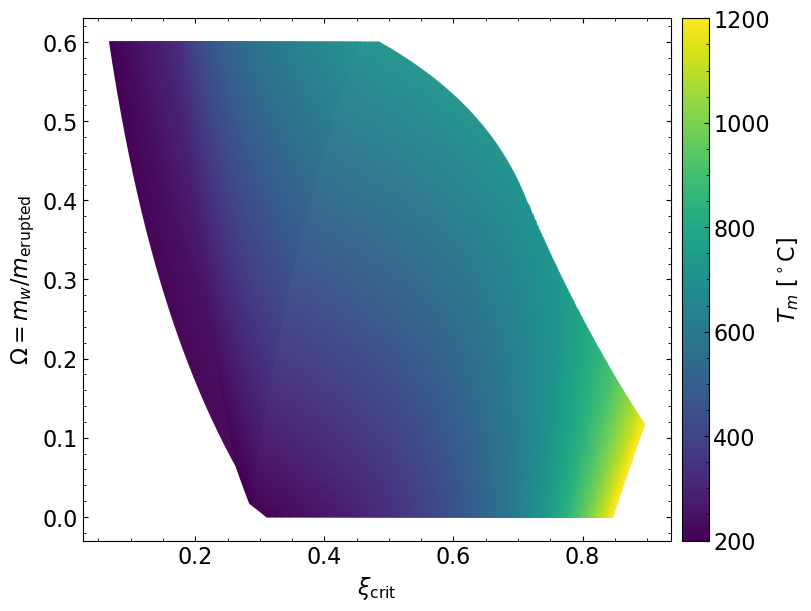

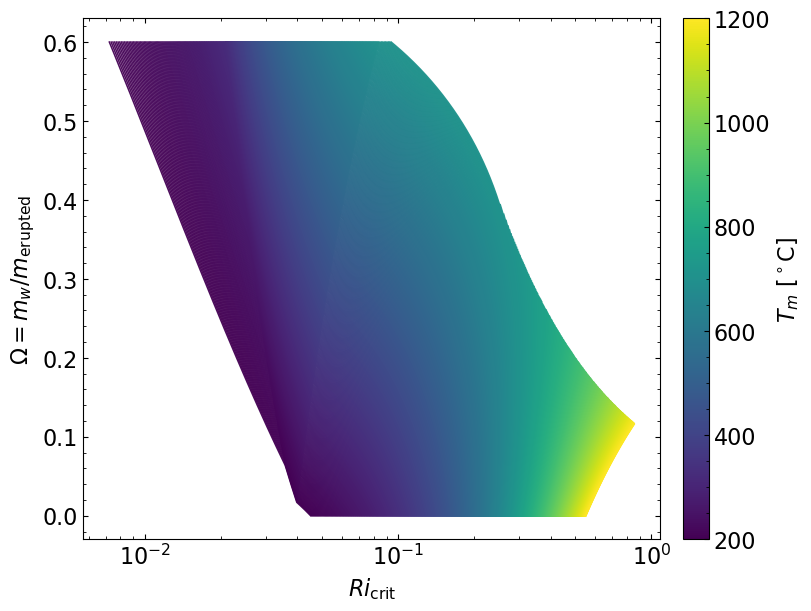

In [73]:
plot_xi_vs_Omega_by_temperature(dfT_main)
plot_Ri_vs_Omega_by_temperature(dfT_main)

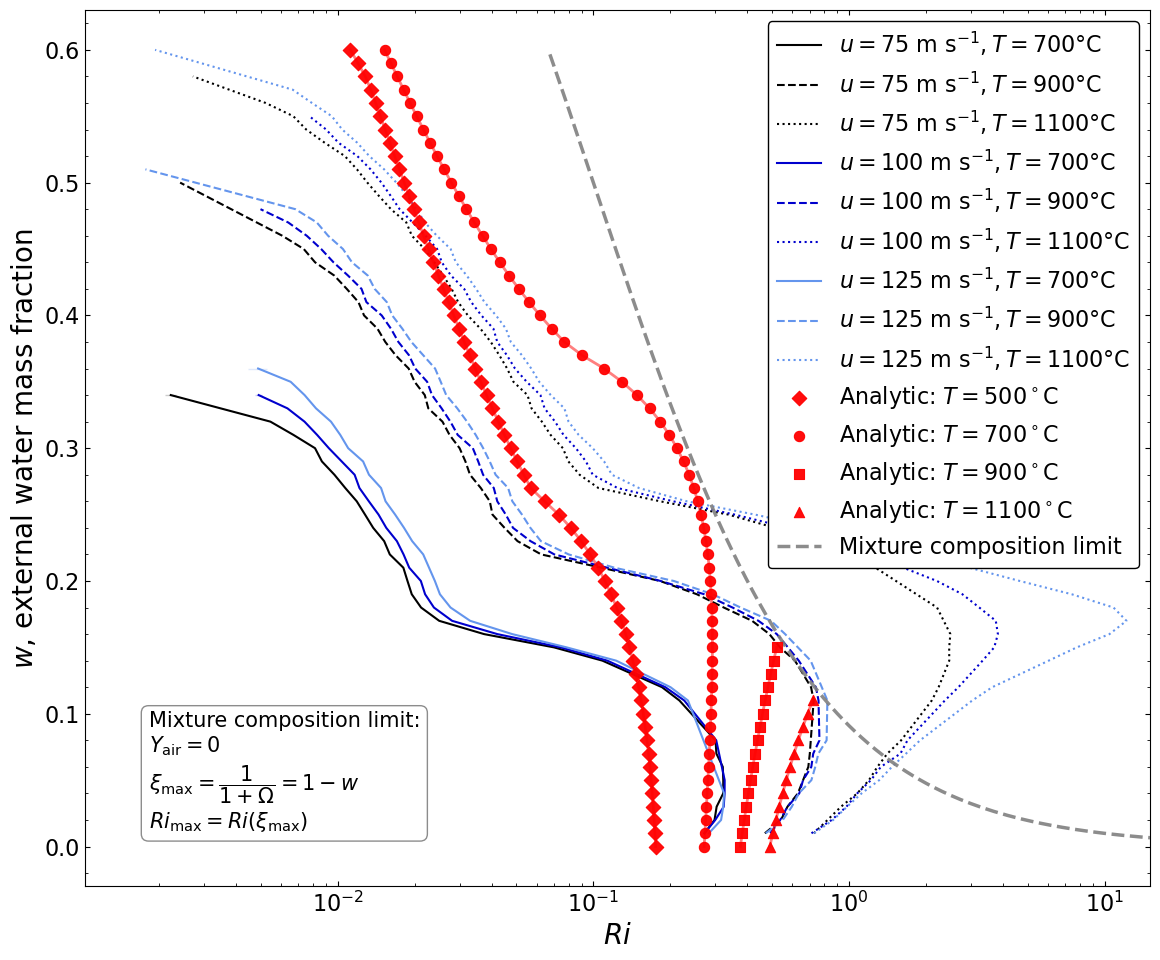

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
from mpl_toolkits.axisartist.axislines import AxesZero
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# define constants for column names
X = 'mass flux total (kg/s)'
Y = 'mass fraction water added'
Z = 'calculated height (km)'
Z_DRY = 'dry plume height (km)'
DELTA_Z = 'delta z (km)'
MER = 'mass flux (kg/s)'
VEL = 'initial velocity (m/s)'
TEMP = 'magma temperature (c)'
RI = 'Ri'

# -----------------------------
# LOAD SAVED NUMERICAL PLOT DATA
# -----------------------------

CSV_PATH = 'plumeria_data/Ri_w_plot_data_paper_definition.csv'
plot_df = pd.read_csv(CSV_PATH)

# Do not convert the numerical water axis.
# Use the saved plotting column directly.
plot_df["water_plot"] = plot_df[Y]

# split saved plotting data back into the 9 curves
curve_names = [
    "u75_T700",
    "u75_T900",
    "u75_T1100",
    "u100_T700",
    "u100_T900",
    "u100_T1100",
    "u125_T700",
    "u125_T900",
    "u125_T1100",
]

dataframes_reduced = [
    plot_df.loc[plot_df["curve"] == curve_name].copy()
    for curve_name in curve_names
]

# -----------------------------
# ANALYTICAL DATA: NEW OMEGA-LOADING MODEL,
# BUT PLOTTED AS SOURCE WATER FRACTION w
# -----------------------------

Tm_vals_K = np.array([500, 700, 900, 1100]) + 273.15

# comparison water axis, matching Carrillo-style source water fraction
w_vals = np.linspace(0.0, 0.60, 61)

# convert comparison w to Omega for the new analytical model
Omega_vals = w_vals / (1.0 - w_vals)

p = default_params()
df_analytic = sweep_temperature_and_Omega(Tm_vals_K, Omega_vals, p)
df_analytic["T_C"] = df_analytic["T_m"] - 273.15

# convert analytical Omega back to source-style w for plotting only
df_analytic["w_compare"] = df_analytic["Omega"] / (1.0 + df_analytic["Omega"])

# use the same plotting column name as the numerical data
df_analytic["water_plot"] = df_analytic["w_compare"]

# -----------------------------
# KEEP ONLY DRY-CONNECTED ANALYTICAL BRANCH
# Stop each T curve after it first hits the xi-limit / loses admissibility
# -----------------------------

def keep_main_branch_until_limit(df, group_col="T_C", yair_stop=1e-3):
    df = df.copy()
    df["main_branch"] = False
    df["branch_stop_reason"] = ""

    for T in np.sort(df[group_col].dropna().unique()):
        idx = df.index[df[group_col] == T]
        idx = df.loc[idx].sort_values("Omega").index

        started = False
        alive = True

        for j in idx:
            if not alive:
                continue

            xi = df.at[j, "xi_crit"]

            # If the main branch already existed and then no root appears,
            # terminate the curve permanently.
            if not np.isfinite(xi):
                if started:
                    alive = False
                    df.at[j, "branch_stop_reason"] = "gap_after_main_branch"
                continue

            started = True
            Omega = df.at[j, "Omega"]

            # Use stored air fraction if available; otherwise compute it.
            if "Y_air_crit" in df.columns and np.isfinite(df.at[j, "Y_air_crit"]):
                Y_air = df.at[j, "Y_air_crit"]
            else:
                Y_air = 1.0 - xi * (1.0 + Omega)

            df.at[j, "main_branch"] = True

            # Keep this endpoint, then terminate anything after it.
            if Y_air <= yair_stop:
                alive = False
                df.at[j, "branch_stop_reason"] = "hit_xi_limit"

    return df


df_analytic = keep_main_branch_until_limit(df_analytic, yair_stop=1e-3)
df_analytic_plot = df_analytic[df_analytic["main_branch"]].copy()


# -----------------------------
# PLOT PARAMETERS
# -----------------------------

params = {
    'legend.title_fontsize': 'xx-small',
    'axes.labelsize': 20,
    'font.size': 20,
    'legend.fontsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.top': True,
    'ytick.right': True,
    'figure.autolayout': True
}
plt.rcParams.update(params)

# -----------------------------
# PLOT
# -----------------------------

size = [12, 10]
f, ax = plt.subplots(figsize=size)

colors = [
    'black', 'black', 'black',
    'mediumblue', 'mediumblue', 'mediumblue',
    'cornflowerblue', 'cornflowerblue', 'cornflowerblue'
]

linestyles = [
    'solid', 'dashed', 'dotted',
    'solid', 'dashed', 'dotted',
    'solid', 'dashed', 'dotted'
]

labels = [
    r'$u = 75 $ m s$^{-1}, T = 700$°C',
    r'$u = 75$ m s$^{-1}, T = 900$°C',
    r'$u = 75$ m s$^{-1}, T = 1100$°C',
    r'$u = 100$ m s$^{-1}, T = 700$°C',
    r'$u = 100$ m s$^{-1}, T = 900$°C',
    r'$u = 100$ m s$^{-1}, T = 1100$°C',
    r'$u = 125$ m s$^{-1}, T = 700$°C',
    r'$u = 125$ m s$^{-1}, T = 900$°C',
    r'$u = 125$ m s$^{-1}, T = 1100$°C'
]

# -----------------------------
# NUMERICAL PLOTTING
# -----------------------------

for df_num, color, linestyle, label in zip(dataframes_reduced, colors, linestyles, labels):
    df_num = df_num.dropna(subset=[RI, "water_plot"])

    sns.lineplot(
        data=df_num,
        x=RI,
        y="water_plot",
        color=color,
        linestyle=linestyle,
        sort=True,
        orient='y',
        label=label,
        ax=ax
    )

# -----------------------------
# ADD ANALYTICAL LINES ON TOP
# -----------------------------

analytic_marker_map = {
    500: "D",
    700: "o",
    900: "s",
    1100: "^",
}

analytic_label_map = {
    500: r'Analytic: $T = 500^\circ$C',
    700: r'Analytic: $T = 700^\circ$C',
    900: r'Analytic: $T = 900^\circ$C',
    1100: r'Analytic: $T = 1100^\circ$C',
}

for T_C in [500, 700, 900, 1100]:
    sub = df_analytic_plot[np.isclose(df_analytic_plot["T_C"], T_C, atol=1e-6)].copy()
    sub = sub.dropna(subset=["Ri_crit", "water_plot"])
    sub = sub.sort_values("water_plot")

    if sub.empty:
        continue

    ax.plot(
        sub["Ri_crit"].to_numpy(),
        sub["water_plot"].to_numpy(),
        color="red",
        linestyle="-",
        linewidth=2.0,
        alpha=0.5,
        zorder=10,
    )

    ax.scatter(
        sub["Ri_crit"].to_numpy(),
        sub["water_plot"].to_numpy(),
        marker=analytic_marker_map[T_C],
        s=55,
        linewidths=0.8,
        alpha=0.95,
        label=analytic_label_map[T_C],
        zorder=11,
        color="red"
    )

# -----------------------------
# ANALYTIC COMPOSITION LIMIT IN Ri-w SPACE
# xi_max = 1 - w, so Ri_max = C*k*xi_max/(1 - xi_max)
# -----------------------------

w_line = np.linspace(1e-3, 0.60, 400)
xi_max_line = 1.0 - w_line

Ri_max_line = np.array([
    Ri_of_xi(xi, p)
    for xi in xi_max_line
])

ax.plot(
    Ri_max_line,
    w_line,
    color="gray",
    linestyle="--",
    linewidth=2.5,
    alpha=0.9,
    label=r"Mixture composition limit", # $\xi=\xi_{\max}
    zorder=5,
)

ax.set(
    ylabel=r'$w$, external water mass fraction',
    xlabel=r'$Ri$',
    xscale='log'
)


# -----------------------------
# TEXT BOX: MIXTURE COMPOSITION LIMIT
# -----------------------------

limit_text = (
    r"Mixture composition limit:" "\n"
    r"$Y_{\rm air}=0$" "\n"
    r"$\xi_{\max}=\dfrac{1}{1+\Omega}=1-w$" "\n"
    r"$Ri_{\max}=Ri(\xi_{\max})$"
)

ax.text(
    0.06,
    0.06,
    limit_text,
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=15,
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="gray",
        alpha=0.9,
    ),
    zorder=20,
)
ax.minorticks_on()
plt.xlim(right=15)

plt.legend(loc=0, ncol=1, frameon=True, framealpha=1, edgecolor='black')

# plt.savefig("main_Ri_fig.png", dpi=300, bbox_inches="tight")
plt.show()

In [75]:

import pandas as pd
import numpy as np


def find_regime_transition_loci(
    df,
    water_col="Omega",
    group_col="T_m_C",
):
    """
    Finds approximate regime-transition locations by detecting where
    regime labels change along each temperature curve.

    The transition point is placed midway between neighboring points,
    using geometric mean in Ri because the x-axis is logarithmic.
    """

    dfp = df.copy()
    dfp = dfp.dropna(subset=["Ri_crit", water_col, group_col, "regime"])
    dfp = dfp[dfp["Ri_crit"] > 0]

    rows = []

    order = {"A": 0, "B": 1, "C": 2}

    for Tm_C, sub in dfp.groupby(group_col):
        sub = sub.sort_values(water_col).reset_index(drop=True)

        for i in range(len(sub) - 1):
            reg0 = sub.loc[i, "regime"]
            reg1 = sub.loc[i + 1, "regime"]

            if reg0 == reg1:
                continue

            Ri0 = sub.loc[i, "Ri_crit"]
            Ri1 = sub.loc[i + 1, "Ri_crit"]

            w0 = sub.loc[i, water_col]
            w1 = sub.loc[i + 1, water_col]

            # log-space midpoint for Ri
            Ri_mid = np.sqrt(Ri0 * Ri1)
            w_mid = 0.5 * (w0 + w1)

            transition = "-".join(
                sorted([reg0, reg1], key=lambda r: order.get(r, 99))
            )

            rows.append(
                {
                    group_col: Tm_C,
                    "Ri_boundary": Ri_mid,
                    water_col: w_mid,
                    "transition": transition,
                    "regime_before": reg0,
                    "regime_after": reg1,
                }
            )

    return pd.DataFrame(rows)

    
def plot_analytic_clusters_by_regime(
    dfT,
    water_col="Omega",
    water_label=r"$\Omega=m_w/m_{\mathrm{erupted}}$",
    savepath=None,
    show_transition_lines=True,
):
    dfp = dfT.copy()
    dfp = dfp.dropna(subset=["Ri_crit", water_col, "T_m_C", "regime"])

    markers = {
        "A": "o",
        "B": "s",
        "C": "^",
    }

    regime_labels = {
        "A": "A: no boiling",
        "B": "B: partial boiling",
        "C": "C: complete vaporization",
    }

    cmap = cm.viridis
    norm = colors.Normalize(
        vmin=dfp["T_m_C"].min(),
        vmax=dfp["T_m_C"].max()
    )

    fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

    # -----------------------------
    # Scatter points by regime
    # -----------------------------

    for reg in ["A", "B", "C"]:
        sub = dfp[dfp["regime"] == reg]

        if sub.empty:
            continue

        ax.scatter(
            sub["Ri_crit"],
            sub[water_col],
            c=sub["T_m_C"],
            cmap=cmap,
            norm=norm,
            marker=markers[reg],
            s=45,
            edgecolors="black",
            linewidths=0.4,
            alpha=0.9,
            label=regime_labels[reg],
            zorder=3,
        )

    # -----------------------------
    # Regime transition lines
    # -----------------------------

    if show_transition_lines:
        bdf = find_regime_transition_loci(
            dfp,
            water_col=water_col,
            group_col="T_m_C",
        )

        transition_styles = {
            "A-B": {
                "label": r"Boiling onset boundary",
                "linestyle": "--",
                "linewidth": 2.2,
            },
            "B-C": {
                "label": r"Complete-vaporization" +"\nboundary",
                "linestyle": "-.",
                "linewidth": 2.2,
            },
            "A-C": {
                "label": r"Unresolved A/C jump",
                "linestyle": ":",
                "linewidth": 2.4,
            },
        }

        for transition, style in transition_styles.items():
            sub = bdf[bdf["transition"] == transition].copy()

            if sub.empty:
                continue

            sub = sub.sort_values(water_col)

            ax.plot(
                sub["Ri_boundary"],
                sub[water_col],
                color="red",
                linestyle=style["linestyle"],
                linewidth=style["linewidth"],
                alpha=0.85,
                label=style["label"],
                zorder=6,
            )

    ax.set_xscale("log")
    ax.set_xlabel(r"$Ri_{\mathrm{crit}}$")
    ax.set_ylabel(water_label)
    ax.minorticks_on()

    ax.legend(
        title="Regime",
        frameon=True,
        fontsize=10,
        title_fontsize=12,
        loc="best",
    )

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label(r"$T_m$ [$^\circ$C]")

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

    plt.show()

In [76]:
# plot_analytic_clusters_by_regime(
#     dfT,
#     water_col="Omega",
#     water_label=r"$\Omega=m_w/m_{\mathrm{erupted}}$",
#     savepath="Ri_Omega_regime_boundaries.png",
# )

In [77]:
from matplotlib import cm, colors
from matplotlib.lines import Line2D
import numpy as np
import matplotlib.pyplot as plt


def ensure_normalized_xi(dfT):
    dfp = dfT.copy()

    if "xi_crit_hat" not in dfp.columns:
        if "xi_dry_ref" not in dfp.columns:
            raise ValueError(
                "dfT needs either 'xi_crit_hat' or 'xi_dry_ref' to compute normalized xi."
            )

        dfp["xi_crit_hat"] = np.nan

        mask = (
            np.isfinite(dfp["xi_crit"])
            & np.isfinite(dfp["xi_dry_ref"])
            & (dfp["xi_dry_ref"] != 0.0)
        )

        dfp.loc[mask, "xi_crit_hat"] = (
            dfp.loc[mask, "xi_crit"] / dfp.loc[mask, "xi_dry_ref"]
        )

    return dfp


def plot_xi_and_xihat_by_temperature_regime_subplots(
    dfT,
    water_col="w_compare",
    water_label=r"$w$",
    Tm_requested=(500, 600, 700, 800, 900, 1000, 1100),
    savepath="xi_and_xihat_by_temperature_regime.png",
):
    dfp = ensure_normalized_xi(dfT)

    # Force numeric columns
    dfp["T_m_C"] = np.asarray(dfp["T_m_C"], dtype=float)
    dfp["xi_crit"] = np.asarray(dfp["xi_crit"], dtype=float)
    dfp["xi_crit_hat"] = np.asarray(dfp["xi_crit_hat"], dtype=float)
    dfp[water_col] = np.asarray(dfp[water_col], dtype=float)

    dfp = dfp.dropna(
        subset=["T_m_C", "xi_crit", "xi_crit_hat", water_col, "regime"]
    )

    dfp = dfp[
        (dfp["xi_crit"] > 0)
        & (dfp["xi_crit"] < 1)
        & (dfp["xi_crit_hat"] > 0)
    ]

    if dfp.empty:
        raise ValueError("No valid rows for xi plotting.")

    Tm_requested = np.asarray(Tm_requested, dtype=float)

    Tm_plot = []
    for T in Tm_requested:
        if np.any(np.isclose(dfp["T_m_C"], T, atol=1e-6)):
            Tm_plot.append(T)

    Tm_plot = np.asarray(Tm_plot, dtype=float)

    if Tm_plot.size == 0:
        raise ValueError("None of the requested T_m values are present in dfT.")

    cmap = cm.viridis

    if Tm_plot.size == 1:
        norm = colors.Normalize(vmin=Tm_plot[0] - 1.0, vmax=Tm_plot[0] + 1.0)
    else:
        norm = colors.Normalize(vmin=Tm_plot.min(), vmax=Tm_plot.max())

    regime_marker_map = {
        "A": "o",
        "B": "s",
        "C": "^",
    }

    regime_label_map = {
        "A": "Regime A: no boiling",
        "B": "Regime B: partial boiling",
        "C": "Regime C: complete vaporization",
    }

    fig, axes = plt.subplots(
        1, 2,
        figsize=(14, 6),
        constrained_layout=True,
        sharey=True,
    )

    ax0, ax1 = axes

    for Tm_C in Tm_plot:
        subT = dfp[np.isclose(dfp["T_m_C"], Tm_C, atol=1e-6)].copy()
        color = cmap(norm(Tm_C))

        for reg in ["A", "B", "C"]:
            sub = subT[subT["regime"] == reg].sort_values(water_col)

            if sub.empty:
                continue

            marker = regime_marker_map[reg]

            # left: raw xi
            ax0.scatter(
                sub["xi_crit"],
                sub[water_col],
                marker=marker,
                s=48,
                color=color,
                edgecolors="black",
                linewidths=0.4,
                alpha=0.95,
                zorder=3,
            )

            # right: normalized xi
            ax1.scatter(
                sub["xi_crit_hat"],
                sub[water_col],
                marker=marker,
                s=48,
                color=color,
                edgecolors="black",
                linewidths=0.4,
                alpha=0.95,
                zorder=3,
            )

    ax0.set_xlabel(r"$\xi_{\mathrm{crit}}$", fontsize=18, labelpad=10)
    ax0.set_ylabel(water_label, fontsize=18, labelpad=12)

    ax1.set_xlabel(
        r"$\xi_{\mathrm{crit}}/\xi_{\mathrm{crit,dry}}$",
        fontsize=18,
        labelpad=10,
    )

    dry_line = ax1.axvline(
    1.0,
    color="black",
    linestyle="--",
    linewidth=1.2,
    alpha=0.8,
    zorder=1,
    label=r"Dry-reference threshold",
)

    # ax1.text(
    #     0.45,
    #     0.95,
    #     "collapse-prone",
    #     transform=ax1.transAxes,
    #     ha="right",
    #     va="top",
    #     fontsize=13,
    # )

    # ax1.text(
    #     0.55,
    #     0.95,
    #     "buoyant-tendencies",
    #     transform=ax1.transAxes,
    #     ha="left",
    #     va="top",
    #     fontsize=13,
    # )

    for ax in axes:
        ax.tick_params(axis="both", which="major", labelsize=16, pad=6)
        ax.tick_params(axis="both", which="minor", labelsize=14)
        ax.minorticks_on()

    # temperature colorbar
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=axes, pad=0.02)
    cbar.set_label(r"$T_m$ [$^\circ$C]", fontsize=16)
    cbar.ax.tick_params(labelsize=14)
    cbar.set_ticks(Tm_plot)
    cbar.set_ticklabels([f"{T:.0f}" for T in Tm_plot])

    handles = [
    Line2D(
        [0], [0],
        marker=regime_marker_map[reg],
        color="none",
        markerfacecolor="gray",
        markeredgecolor="black",
        markersize=8,
        linestyle="none",
        label=regime_label_map[reg],
    )
    for reg in ["A", "B", "C"]
]

    handles.append(dry_line)

    ax1.legend(
    handles=handles,
    loc="best",
    frameon=True,
    fontsize=11,
)
    # ax1.legend(handles=handles, loc="best", frameon=True, fontsize=11)

    # fig.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.show()

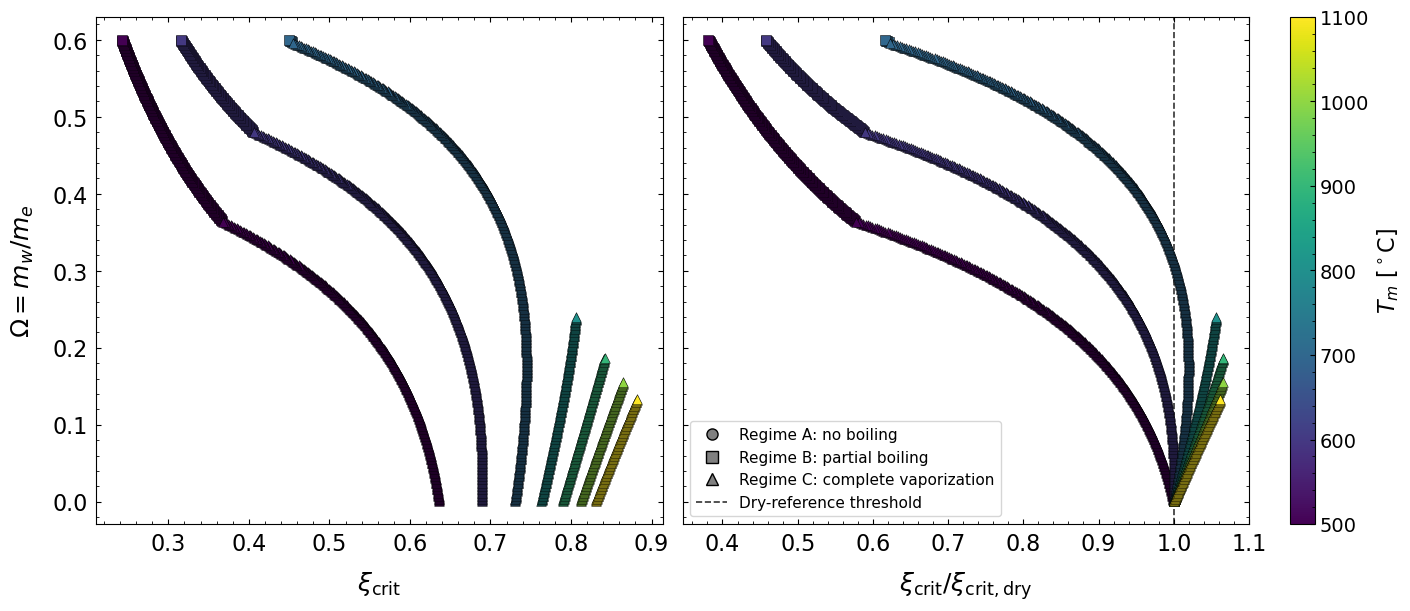

In [78]:
plot_xi_and_xihat_by_temperature_regime_subplots(
    dfT,
    water_col="Omega",
    water_label=r"$\Omega=m_w/m_e$",
    savepath="xi_and_xihat_by_temperature_regime_Omega.png",
)

In [ ]:
# plot_Ri_and_Rihat_by_temperature_regime_subplots(
#     dfT,
#     water_col="Omega",
#     water_label=r"$\Omega=m_w/m_e$",
# )

In [ ]:
# plt.figure(figsize=(7, 6))

# plt.scatter(
#     dfT["xi_crit"],
#     dfT["Omega"],
#     c=dfT["T_m_C"],
#     cmap="viridis",
#     s=45,
#     edgecolors="black",
#     linewidths=0.4,
# )

# Omega_line = np.linspace(dfT["Omega"].min(), dfT["Omega"].max(), 300)

# plt.plot(
#     1.0 / (1.0 + Omega_line),
#     Omega_line,
#     "k--",
#     lw=2,
#     label=r"$\xi_{\max}=1/(1+\Omega)$",
# )

# plt.xlabel(r"$\xi_{\mathrm{crit}}$", fontsize=16)
# plt.ylabel(r"$\Omega=m_w/m_e$", fontsize=16)
# plt.colorbar(label=r"$T_m$ [$^\circ$C]")
# plt.legend()
# plt.show()

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_regime_transition_loci_xi(
    df,
    water_col="Omega",
    group_col="T_m_C",
):
    """
    Estimate regime-transition points from discrete regime labels.
    Boundaries are placed midway between adjacent points where regime changes.
    """

    dfp = df.copy()
    dfp = dfp.dropna(subset=["xi_crit", water_col, group_col, "regime"])
    dfp = dfp[np.isfinite(dfp["xi_crit"])]

    rows = []

    order = {"A": 0, "B": 1, "C": 2}

    for Tm_C, sub in dfp.groupby(group_col):
        sub = sub.sort_values(water_col).reset_index(drop=True)

        for i in range(len(sub) - 1):
            reg0 = sub.loc[i, "regime"]
            reg1 = sub.loc[i + 1, "regime"]

            if reg0 == reg1:
                continue

            xi0 = sub.loc[i, "xi_crit"]
            xi1 = sub.loc[i + 1, "xi_crit"]

            Om0 = sub.loc[i, water_col]
            Om1 = sub.loc[i + 1, water_col]

            xi_mid = 0.5 * (xi0 + xi1)
            Om_mid = 0.5 * (Om0 + Om1)

            transition = "-".join(
                sorted([reg0, reg1], key=lambda r: order.get(r, 99))
            )

            rows.append(
                {
                    group_col: Tm_C,
                    "xi_boundary": xi_mid,
                    water_col: Om_mid,
                    "transition": transition,
                    "regime_before": reg0,
                    "regime_after": reg1,
                }
            )

    return pd.DataFrame(rows)



In [88]:
# fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)

# dfp = dfT.dropna(subset=["xi_crit", "Omega", "T_m_C", "regime"]).copy()

# cmap = plt.cm.viridis
# norm = plt.Normalize(dfp["T_m_C"].min(), dfp["T_m_C"].max())

# # -----------------------------
# # xi_crit curves by temperature
# # -----------------------------

# for Tm_C in np.sort(dfp["T_m_C"].unique()):
#     sub = dfp[np.isclose(dfp["T_m_C"], Tm_C)].sort_values("Omega")

#     ax.plot(
#         sub["xi_crit"],
#         sub["Omega"],
#         color=cmap(norm(Tm_C)),
#         lw=1.5,
#         alpha=0.95,
#         zorder=3,
#     )

# # -----------------------------
# # xi_max composition limit
# # -----------------------------

# Omega_line = np.linspace(dfp["Omega"].min(), dfp["Omega"].max(), 300)

# ax.plot(
#     1.0 / (1.0 + Omega_line),
#     Omega_line,
#     "k--",
#     lw=2,
#     label=r"Mixture composition"+"\n"+r"limit, $Y_{\rm air}=0$",
#     zorder=5,
#     # color = "r"
# )

# # -----------------------------
# # regime transition boundaries
# # -----------------------------

# bdf = find_regime_transition_loci_xi(
#     dfp,
#     water_col="Omega",
#     group_col="T_m_C",
# )

# transition_styles = {
#     "A-B": {
#         "label": r"Boiling onset boundary",
#         "linestyle": "--",
#         "linewidth": 2.0,
#     },
#     "B-C": {
#         "label": r"Complete-vaporization"+"\nboundary",
#         "linestyle": "dotted",
#         "linewidth": 2.0,
#     },
#     "A-C": {
#         "label": r"Unresolved A/C jump",
#         "linestyle": ":",
#         "linewidth": 2.3,
#     },
# }

# for transition, style in transition_styles.items():
#     sub = bdf[bdf["transition"] == transition].copy()

#     if sub.empty:
#         continue

#     sub = sub.sort_values("Omega")

#     ax.plot(
#         sub["xi_boundary"],
#         sub["Omega"],
#         color="red",
#         linestyle=style["linestyle"],
#         linewidth=style["linewidth"],
#         alpha=0.85,
#         label=style["label"],
#         zorder=6,
#     )

# # -----------------------------
# # labels, colorbar, save
# # -----------------------------

# ax.set_xlabel(r"$\xi_{\mathrm{crit}}$", fontsize=16)
# ax.set_ylabel(r"$\Omega=m_w/m_e$", fontsize=16)

# sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
# sm.set_array([])
# cbar = fig.colorbar(sm, ax=ax, pad=0.02)
# cbar.set_label(r"$T_m$ [$^\circ$C]")

# ax.legend(frameon=True, fontsize=10)
# ax.minorticks_on()

# fig.savefig("xi_limit_regime_boundaries.png", dpi=300, bbox_inches="tight")

# plt.show()

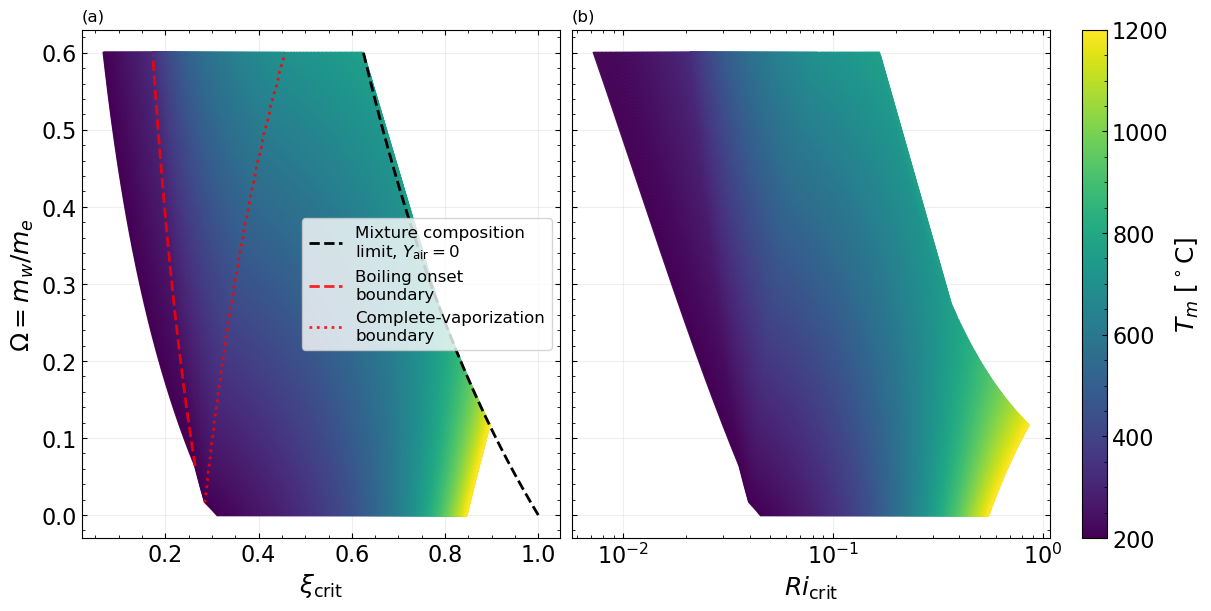

In [90]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Two-panel xi and Ri threshold figure
# ============================================================

dfp = dfT.dropna(subset=["xi_crit", "Omega", "T_m_C", "regime"]).copy()

# ------------------------------------------------------------
# If Ri_crit is not already in dfT, compute a proportional form
# Replace this with your exact Ri mapping if needed.
# ------------------------------------------------------------

if "Ri_crit" not in dfp.columns:
    dfp["Ri_crit"] = dfp["xi_crit"] / (1.0 - dfp["xi_crit"])

# ------------------------------------------------------------
# Figure setup
# ------------------------------------------------------------

fig, (ax_xi, ax_ri) = plt.subplots(
    1, 2,
    figsize=(12, 6),
    sharey=True,
    constrained_layout=True
)

cmap = plt.cm.viridis
norm = plt.Normalize(dfp["T_m_C"].min(), dfp["T_m_C"].max())

# ============================================================
# Left panel: xi_crit curves by temperature
# ============================================================

for Tm_C in np.sort(dfp["T_m_C"].unique()):
    sub = dfp[np.isclose(dfp["T_m_C"], Tm_C)].sort_values("Omega")

    ax_xi.plot(
        sub["xi_crit"],
        sub["Omega"],
        color=cmap(norm(Tm_C)),
        lw=1.5,
        alpha=0.95,
        zorder=3,
    )

# ------------------------------------------------------------
# xi_max composition limit
# ------------------------------------------------------------

Omega_line = np.linspace(dfp["Omega"].min(), dfp["Omega"].max(), 300)

ax_xi.plot(
    1.0 / (1.0 + Omega_line),
    Omega_line,
    "k--",
    lw=2,
    label=r"Mixture composition" + "\n" + r"limit, $Y_{\rm air}=0$",
    zorder=5,
)

# ------------------------------------------------------------
# Regime transition boundaries
# ------------------------------------------------------------

bdf = find_regime_transition_loci_xi(
    dfp,
    water_col="Omega",
    group_col="T_m_C",
)

transition_styles = {
    "A-B": {
        "label": r"Boiling onset" + "\nboundary",
        "linestyle": "--",
        "linewidth": 2.0,
    },
    "B-C": {
        "label": r"Complete-vaporization" + "\n" + r"boundary",
        "linestyle": "dotted",
        "linewidth": 2.0,
    },
    "A-C": {
        "label": r"Unresolved A/C jump",
        "linestyle": ":",
        "linewidth": 2.3,
    },
}

for transition, style in transition_styles.items():
    sub = bdf[bdf["transition"] == transition].copy()

    if sub.empty:
        continue

    sub = sub.sort_values("Omega")

    ax_xi.plot(
        sub["xi_boundary"],
        sub["Omega"],
        color="red",
        linestyle=style["linestyle"],
        linewidth=style["linewidth"],
        alpha=0.85,
        label=style["label"],
        zorder=6,
    )

# ============================================================
# Right panel: Ri_crit curves by temperature
# ============================================================

for Tm_C in np.sort(dfp["T_m_C"].unique()):
    sub = dfp[np.isclose(dfp["T_m_C"], Tm_C)].sort_values("Omega")

    ax_ri.plot(
        sub["Ri_crit"],
        sub["Omega"],
        color=cmap(norm(Tm_C)),
        lw=1.5,
        alpha=0.95,
        zorder=3,
    )

# ============================================================
# Labels and formatting
# ============================================================

ax_xi.set_xlabel(r"$\xi_{\mathrm{crit}}$", fontsize=18)
ax_xi.set_ylabel(r"$\Omega=m_w/m_e$", fontsize=18)

ax_ri.set_xlabel(r"$Ri_{\mathrm{crit}}$", fontsize=18)

ax_xi.set_title(r"(a)", loc="left", fontsize=12)
ax_ri.set_title(r"(b)", loc="left", fontsize=12)

ax_xi.legend(frameon=True, fontsize=12, loc="center right")

for ax in (ax_xi, ax_ri):
    ax.minorticks_on()
    ax.grid(True, alpha=0.2)

# Optional if Ri spans a wide range:
ax_ri.set_xscale("log")

# ------------------------------------------------------------
# Shared colorbar
# ------------------------------------------------------------

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=[ax_xi, ax_ri],
    pad=0.02,
)

cbar.set_label(r"$T_m$ [$^\circ$C]", fontsize=18)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

# fig.savefig("xi_and_Ri_thresholds_by_temperature.png", dpi=300, bbox_inches="tight")
plt.show()

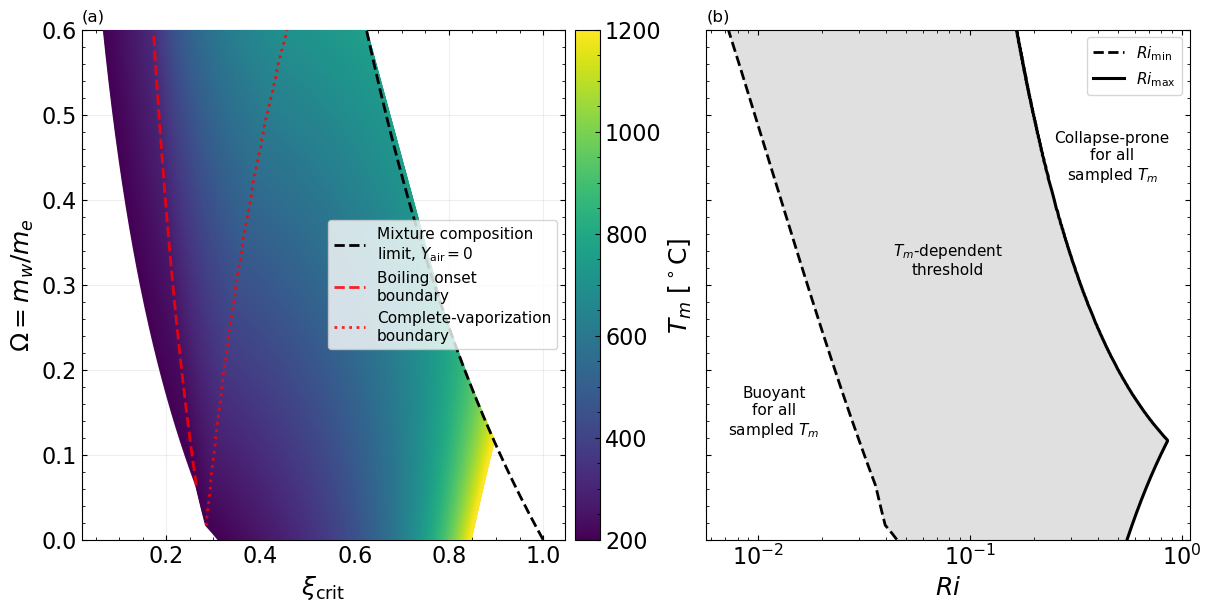

In [91]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# NEW FIGURE:
# xi_crit threshold family + Ri envelope regime map
# ============================================================

dfp_env = dfT.dropna(
    subset=["xi_crit", "Omega", "T_m_C", "regime"]
).copy()

# ------------------------------------------------------------
# Richardson-number mapping
# Use existing Ri_crit if already present; otherwise compute it
# ------------------------------------------------------------

if "Ri_crit" not in dfp_env.columns:
    dfp_env["Ri_crit"] = (
        dfp_env["xi_crit"] /
        (1.0 - dfp_env["xi_crit"])
    )

# ------------------------------------------------------------
# Figure setup
# ------------------------------------------------------------

fig, (ax_xi, ax_ri) = plt.subplots(
    1, 2,
    figsize=(12, 6),
    sharey=True,
    constrained_layout=True,
)

cmap = plt.cm.viridis
norm = plt.Normalize(
    dfp_env["T_m_C"].min(),
    dfp_env["T_m_C"].max(),
)

# ============================================================
# (a) xi_crit threshold family
# ============================================================

for Tm_C in np.sort(dfp_env["T_m_C"].unique()):

    sub = (
        dfp_env[np.isclose(dfp_env["T_m_C"], Tm_C)]
        .sort_values("Omega")
    )

    ax_xi.plot(
        sub["xi_crit"],
        sub["Omega"],
        color=cmap(norm(Tm_C)),
        lw=1.5,
        alpha=0.95,
        zorder=3,
    )

# ------------------------------------------------------------
# Mixture-composition limit
# ------------------------------------------------------------

Omega_line = np.linspace(
    dfp_env["Omega"].min(),
    dfp_env["Omega"].max(),
    300,
)

ax_xi.plot(
    1.0 / (1.0 + Omega_line),
    Omega_line,
    "k--",
    lw=2,
    label=r"Mixture composition" + "\n" + r"limit, $Y_{\rm air}=0$",
    zorder=5,
)

# ------------------------------------------------------------
# Thermodynamic-regime boundaries
# ------------------------------------------------------------

bdf = find_regime_transition_loci_xi(
    dfp_env,
    water_col="Omega",
    group_col="T_m_C",
)

transition_styles = {
    "A-B": {
        "label": "Boiling onset\nboundary",
        "linestyle": "--",
        "linewidth": 2.0,
    },
    "B-C": {
        "label": "Complete-vaporization\nboundary",
        "linestyle": "dotted",
        "linewidth": 2.0,
    },
    "A-C": {
        "label": "Unresolved A/C jump",
        "linestyle": ":",
        "linewidth": 2.3,
    },
}

for transition, style in transition_styles.items():

    sub = bdf[bdf["transition"] == transition].copy()

    if sub.empty:
        continue

    sub = sub.sort_values("Omega")

    ax_xi.plot(
        sub["xi_boundary"],
        sub["Omega"],
        color="red",
        linestyle=style["linestyle"],
        linewidth=style["linewidth"],
        alpha=0.85,
        label=style["label"],
        zorder=6,
    )

# ============================================================
# (b) Ri envelope regime map
# ============================================================

# At every Omega:
#   Ri_min = smallest threshold among sampled temperatures
#   Ri_max = largest threshold among sampled temperatures

env = (
    dfp_env
    .groupby("Omega", as_index=False)
    .agg(
        Ri_min=("Ri_crit", "min"),
        Ri_max=("Ri_crit", "max"),
        n_T=("T_m_C", "nunique"),
    )
    .sort_values("Omega")
)

# ------------------------------------------------------------
# Plot envelopes
# ------------------------------------------------------------

ax_ri.plot(
    env["Ri_min"],
    env["Omega"],
    color="black",
    linestyle="--",
    lw=2.0,
    label=r"$Ri_{\min}$",
    zorder=5,
)

ax_ri.plot(
    env["Ri_max"],
    env["Omega"],
    color="black",
    linestyle="-",
    lw=2.2,
    label=r"$Ri_{\max}$",
    zorder=6,
)

# ------------------------------------------------------------
# Shade temperature-dependent region
# ------------------------------------------------------------

ax_ri.fill_betweenx(
    env["Omega"],
    env["Ri_min"],
    env["Ri_max"],
    color="0.88",
    alpha=1.0,
    zorder=1,
)

# ============================================================
# Labels
# ============================================================

ax_xi.set_xlabel(
    r"$\xi_{\mathrm{crit}}$",
    fontsize=18,
)

ax_xi.set_ylabel(
    r"$\Omega=m_w/m_e$",
    fontsize=18,
)

ax_ri.set_xlabel(
    r"$Ri$",
    fontsize=18,
)

ax_xi.set_title(
    r"(a)",
    loc="left",
    fontsize=12,
)

ax_ri.set_title(
    r"(b)",
    loc="left",
    fontsize=12,
)

# ------------------------------------------------------------
# Region labels
# ------------------------------------------------------------

ax_ri.text(
    0.14,
    0.25,
    "Buoyant\nfor all\nsampled $T_m$",
    transform=ax_ri.transAxes,
    ha="center",
    va="center",
    fontsize=11,
)

ax_ri.text(
    0.50,
    0.55,
    "$T_m$-dependent\nthreshold",
    transform=ax_ri.transAxes,
    ha="center",
    va="center",
    fontsize=11,
)

ax_ri.text(
    0.84,
    0.75,
    "Collapse-prone\nfor all\nsampled $T_m$",
    transform=ax_ri.transAxes,
    ha="center",
    va="center",
    fontsize=11,
)

# ============================================================
# Formatting
# ============================================================

ax_xi.legend(
    frameon=True,
    fontsize=11,
    loc="center right",
)

ax_ri.legend(
    frameon=True,
    fontsize=11,
    loc="upper right",
)

ax_xi.minorticks_on()
ax_xi.grid(
    True,
    alpha=0.2,
)

ax_ri.minorticks_on()
ax_ri.grid(
    False,
)

# Ri axis
ax_ri.set_xscale("log")

# ------------------------------------------------------------
# Shared temperature colorbar
# Applies to panel (a)
# ------------------------------------------------------------

sm = plt.cm.ScalarMappable(
    norm=norm,
    cmap=cmap,
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax_xi,
    pad=0.02,
)

cbar.set_label(
    r"$T_m$ [$^\circ$C]",
    fontsize=18,
)

# ------------------------------------------------------------
# Save if desired
# ------------------------------------------------------------

# fig.savefig(
#     "xi_threshold_and_Ri_envelope_map.png",
#     dpi=300,
#     bbox_inches="tight",
# )
plt.ylim(0, .60)                  # Set bottom=0, top=50

plt.show()

In [92]:
import numpy as np
import pandas as pd


def summarize_temperature_branch(
    df,
    T_target_C,
    water_col="Omega",
    atol=1e-8,
):
    """
    Summarize one fixed-temperature solution branch.

    Returns:
    - dry threshold
    - maximum wet threshold
    - normalized maximum
    - Omega at the maximum
    - regime at the maximum
    - discrete bracket for branch termination
    """

    sub = (
        df.loc[np.isclose(df["T_m_C"], T_target_C, atol=atol)]
        .sort_values(water_col)
        .reset_index(drop=True)
        .copy()
    )

    if sub.empty:
        available = np.sort(df["T_m_C"].dropna().unique())
        raise ValueError(
            f"T_m={T_target_C:g} °C is not available. "
            f"Available range: {available.min():g}--{available.max():g} °C."
        )

    valid = np.isfinite(sub["xi_crit"].to_numpy())
    finite = sub.loc[valid].copy()

    if finite.empty:
        raise ValueError(
            f"No admissible threshold solutions exist at "
            f"T_m={T_target_C:g} °C."
        )

    # Dry-reference threshold for this temperature
    if "xi_dry_ref" in finite.columns:
        xi_dry = finite["xi_dry_ref"].dropna().iloc[0]
    else:
        dry_row = finite.loc[
            (finite[water_col] - 0.0).abs().idxmin()
        ]
        xi_dry = dry_row["xi_crit"]

    # Maximum threshold along the sampled branch
    peak = finite.loc[finite["xi_crit"].idxmax()]

    # First transition from an admissible solution to no admissible root
    transitions = np.flatnonzero(valid[:-1] & ~valid[1:])

    if transitions.size > 0:
        i = int(transitions[0])

        last_valid = sub.iloc[i]
        first_invalid = sub.iloc[i + 1]

        Omega_last = last_valid[water_col]
        Omega_first_no_root = first_invalid[water_col]

        # Midpoint is only an estimate based on the discrete grid
        Omega_termination_estimate = 0.5 * (
            Omega_last + Omega_first_no_root
        )

        xi_last = last_valid["xi_crit"]
        xi_max_last = 1.0 / (1.0 + Omega_last)

        if (
            "Y_air_crit" in last_valid.index
            and np.isfinite(last_valid["Y_air_crit"])
        ):
            Y_air_last = last_valid["Y_air_crit"]
        else:
            Y_air_last = (
                1.0 - (1.0 + Omega_last) * xi_last
            )

    else:
        Omega_last = np.nan
        Omega_first_no_root = np.nan
        Omega_termination_estimate = np.nan
        xi_last = np.nan
        xi_max_last = np.nan
        Y_air_last = np.nan

    return {
        "T_m_C": T_target_C,
        "xi_dry": xi_dry,
        "xi_peak": peak["xi_crit"],
        "percent_increase_above_dry":
            100.0 * (peak["xi_crit"] / xi_dry - 1.0),
        "Omega_at_peak": peak[water_col],
        "regime_at_peak": peak["regime"],
        "Omega_last_admissible": Omega_last,
        "Omega_first_no_root": Omega_first_no_root,
        "Omega_termination_estimate":
            Omega_termination_estimate,
        "xi_last_admissible": xi_last,
        "xi_max_at_last_admissible": xi_max_last,
        "Y_air_at_last_admissible": Y_air_last,
    }


# Choose the temperatures you want to inspect.
# For the paper, one representative temperature may be enough.
temperatures_to_report = [800.0, 1000.0, 1200.0]

branch_summary = pd.DataFrame(
    [
        summarize_temperature_branch(dfT, T)
        for T in temperatures_to_report
    ]
)

print(
    branch_summary.to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}",
    )
)

branch_summary.to_csv(
    "representative_branch_values.csv",
    index=False,
)

    T_m_C  xi_dry  xi_peak  percent_increase_above_dry  Omega_at_peak regime_at_peak  Omega_last_admissible  Omega_first_no_root  Omega_termination_estimate  xi_last_admissible  xi_max_at_last_admissible  Y_air_at_last_admissible
 800.0000  0.7631   0.8061                      5.6371         0.2400              C                 0.2400               0.2410                      0.2405              0.8061                     0.8065                    0.0005
1000.0000  0.8117   0.8647                      6.5238         0.1550              C                 0.1550               0.1560                      0.1555              0.8647                     0.8658                    0.0013
1200.0000  0.8463   0.8953                      5.7807         0.1160              C                 0.1160               0.1170                      0.1165              0.8953                     0.8961                    0.0009


In [94]:
def summarize_regime_envelopes(
    df,
    T_min_C=None,
    T_max_C=None,
    water_col="Omega",
):
    """
    Return the sampled temperature and water-loading envelope
    occupied by each accepted regime.
    """

    work = df.copy()

    if T_min_C is not None:
        work = work.loc[work["T_m_C"] >= T_min_C]

    if T_max_C is not None:
        work = work.loc[work["T_m_C"] <= T_max_C]

    rows = []

    for regime in ["A", "B", "C"]:
        sub = work.loc[
            (work["regime"] == regime)
            & np.isfinite(work["xi_crit"])
            & np.isfinite(work["T_m_C"])
            & np.isfinite(work[water_col])
        ]

        if sub.empty:
            continue

        rows.append({
            "regime": regime,
            "T_min_C": sub["T_m_C"].min(),
            "T_max_C": sub["T_m_C"].max(),
            "Omega_min": sub[water_col].min(),
            "Omega_max": sub[water_col].max(),
            "number_of_sampled_solutions": len(sub),
        })

    return pd.DataFrame(rows)


def find_no_root_onsets(
    df,
    water_col="Omega",
):
    """
    At each temperature, find the first sampled transition from
    an admissible threshold to no admissible threshold.
    """

    rows = []

    for T_m_C, sub in df.groupby("T_m_C", sort=True):
        sub = (
            sub.sort_values(water_col)
            .reset_index(drop=True)
        )

        valid = np.isfinite(sub["xi_crit"].to_numpy())
        transitions = np.flatnonzero(
            valid[:-1] & ~valid[1:]
        )

        if transitions.size == 0:
            continue

        i = int(transitions[0])

        Omega_last = sub.loc[i, water_col]
        Omega_first_no_root = sub.loc[i + 1, water_col]

        rows.append({
            "T_m_C": T_m_C,
            "Omega_last_admissible": Omega_last,
            "Omega_first_no_root": Omega_first_no_root,
            "Omega_transition_estimate":
                0.5 * (Omega_last + Omega_first_no_root),
            "last_admissible_regime":
                sub.loc[i, "regime"],
            "xi_last_admissible":
                sub.loc[i, "xi_crit"],
            "Y_air_last_admissible":
                sub.loc[i, "Y_air_crit"],
        })

    return pd.DataFrame(rows)


# Full diagnostic range used in the regime map
full_regime_envelopes = summarize_regime_envelopes(dfT)

# Representative eruptive range listed in Table 2
representative_regime_envelopes = summarize_regime_envelopes(
    dfT,
    T_min_C=600.0,
    T_max_C=1200.0,
)

no_root_onsets = find_no_root_onsets(dfT)

print("\nFULL DIAGNOSTIC RANGE")
print(full_regime_envelopes.to_string(index=False))

print("\nREPRESENTATIVE 600--1200 °C RANGE")
print(representative_regime_envelopes.to_string(index=False))

print("\nSELECTED BRANCH TERMINATIONS")
print(
    no_root_onsets.loc[
        no_root_onsets["T_m_C"].isin(
            [800.0, 900.0, 1000.0, 1100.0, 1200.0]
        )
    ].to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}",
    )
)

full_regime_envelopes.to_csv(
    "regime_envelopes_full_range.csv",
    index=False,
)

representative_regime_envelopes.to_csv(
    "regime_envelopes_representative_range.csv",
    index=False,
)

no_root_onsets.to_csv(
    "no_root_onsets_by_temperature.csv",
    index=False,
)


FULL DIAGNOSTIC RANGE
regime  T_min_C  T_max_C  Omega_min  Omega_max  number_of_sampled_solutions
     A    200.0    323.0      0.064        0.6                        33556
     B    200.0    703.0      0.017        0.6                       113734
     C    200.0   1200.0      0.001        0.6                       254514

REPRESENTATIVE 600--1200 °C RANGE
regime  T_min_C  T_max_C  Omega_min  Omega_max  number_of_sampled_solutions
     B    600.0    703.0      0.481        0.6                         6299
     C    600.0   1200.0      0.001        0.6                       155505

SELECTED BRANCH TERMINATIONS
    T_m_C  Omega_last_admissible  Omega_first_no_root  Omega_transition_estimate last_admissible_regime  xi_last_admissible  Y_air_last_admissible
1100.0000                 0.1330               0.1340                     0.1335                      C              0.8819                 0.0008
1200.0000                 0.1160               0.1170                     0.1165      

In [95]:
from scipy.optimize import brentq
import numpy as np
import pandas as pd


# ============================================================
# NUMERICAL THERMODYNAMIC STATE
# ============================================================

def numerical_thermo_state(xi, p):
    """
    Evaluate the thermodynamic state at a trial erupted-material
    fraction xi using the same A/B/C regime logic as the
    analytical model.

    Returns
    -------
    T       : mixture temperature [K]
    R_mix   : effective mixture gas constant [J kg^-1 K^-1]
    regime  : "A", "B", or "C"
    H_i     : excess enthalpy relative to saturation [J kg^-1]
    Y_air   : entrained-air mass fraction
    """

    Omega = p["Omega"]

    # --------------------------------------------------------
    # Mixture fractions
    # --------------------------------------------------------

    omega = Omega * xi
    Y_air = 1.0 - (1.0 + Omega) * xi

    # --------------------------------------------------------
    # Excess sensible enthalpy relative to T_sat
    # --------------------------------------------------------

    H_i = (
        xi * p["Cp_m"] * (p["T_m"] - p["T_sat"])
        + Y_air * p["Cp_air"] * (p["T_air"] - p["T_sat"])
        + omega * p["Cp_l"] * (p["T_w0"] - p["T_sat"])
    )

    latent_demand = omega * p["L_v"]

    # ========================================================
    # REGIME A: no boiling
    # ========================================================

    if H_i <= 0.0:

        regime = "A"

        R_mix = (
            xi * p["n"] * p["R_g"]
            + Y_air * p["R_air"]
        )

        numerator = (
            xi * p["Cp_m"] * p["T_m"]
            + Y_air * p["Cp_air"] * p["T_air"]
            + omega * p["Cp_l"] * p["T_w0"]
        )

        denominator = (
            xi * p["Cp_m"]
            + Y_air * p["Cp_air"]
            + omega * p["Cp_l"]
        )

        T = numerator / denominator

    # ========================================================
    # REGIME B: partial boiling
    # ========================================================

    elif H_i < latent_demand:

        regime = "B"

        # final mass fraction of vaporized external water
        omega_vapor = H_i / p["L_v"]

        R_mix = (
            xi * p["n"] * p["R_g"]
            + Y_air * p["R_air"]
            + omega_vapor * p["R_w"]
        )

        T = p["T_sat"]

    # ========================================================
    # REGIME C: complete vaporization + superheating
    # ========================================================

    else:

        regime = "C"

        R_mix = (
            xi * p["n"] * p["R_g"]
            + omega * p["R_w"]
            + Y_air * p["R_air"]
        )

        denominator = (
            xi * p["Cp_m"]
            + Y_air * p["Cp_air"]
            + omega * p["Cp_w"]
        )

        T = (
            p["T_sat"]
            + (H_i - latent_demand) / denominator
        )

    return {
        "T": T,
        "R_mix": R_mix,
        "regime": regime,
        "H_i": H_i,
        "Y_air": Y_air,
        "omega_eff": omega,
    }


# ============================================================
# NEUTRAL-BUOYANCY RESIDUAL
# ============================================================

def neutral_buoyancy_residual(xi, p):
    """
    Residual of the collapse-threshold equation

        R_mix*T - R_air*T_air = 0

    The root is xi_crit.
    """

    state = numerical_thermo_state(xi, p)

    return (
        state["R_mix"] * state["T"]
        - p["R_air"] * p["T_air"]
    )


# ============================================================
# FIND ALL NONTRIVIAL NUMERICAL ROOTS (using brent method)
# ============================================================

def find_numerical_roots(
    p,
    n_scan=3000,
    xi_min=1e-8,
    root_tol=1e-12,
):
    """
    Scan the physical xi interval, bracket sign changes,
    and solve each bracket using Brent's method.

    The trivial xi=0 pure-air root is excluded.
    """

    Omega = p["Omega"]

    xi_max = 1.0 / (1.0 + Omega)

    if xi_max <= xi_min:
        return []

    # Stay infinitesimally inside the composition boundary.
    xi_upper = xi_max * (1.0 - 1e-12)

    # --------------------------------------------------------
    # Base scan
    # --------------------------------------------------------

    xi_grid = np.linspace(
        xi_min,
        xi_upper,
        n_scan
    )

    # --------------------------------------------------------
    # Add exact thermodynamic regime boundaries to the grid.
    #
    # H_i = H0 + H1 xi
    #
    # A/B boundary:
    #     H_i = 0
    #
    # B/C boundary:
    #     H_i = Omega xi L_v
    # --------------------------------------------------------

    H0 = p["Cp_air"] * (
        p["T_air"] - p["T_sat"]
    )

    H1 = (
        p["Cp_m"] * (p["T_m"] - p["T_sat"])
        - (1.0 + Omega)
        * p["Cp_air"]
        * (p["T_air"] - p["T_sat"])
        + Omega
        * p["Cp_l"]
        * (p["T_w0"] - p["T_sat"])
    )

    extra_points = []

    # H0 + H1 xi = 0
    if abs(H1) > 1e-14:
        xi_AB = -H0 / H1

        if xi_min < xi_AB < xi_upper:
            extra_points.append(xi_AB)

    # H0 + H1 xi = Omega xi Lv
    denom_BC = H1 - Omega * p["L_v"]

    if abs(denom_BC) > 1e-14:
        xi_BC = -H0 / denom_BC

        if xi_min < xi_BC < xi_upper:
            extra_points.append(xi_BC)

    if extra_points:
        xi_grid = np.sort(
            np.unique(
                np.concatenate([
                    xi_grid,
                    np.asarray(extra_points)
                ])
            )
        )

    # --------------------------------------------------------
    # Evaluate residual
    # --------------------------------------------------------

    F = np.asarray([
        neutral_buoyancy_residual(xi, p)
        for xi in xi_grid
    ])

    roots = []

    # --------------------------------------------------------
    # Bracket roots
    # --------------------------------------------------------

    for i in range(len(xi_grid) - 1):

        x1 = xi_grid[i]
        x2 = xi_grid[i + 1]

        f1 = F[i]
        f2 = F[i + 1]

        if not (
            np.isfinite(f1)
            and np.isfinite(f2)
        ):
            continue

        # Root exactly on sampled point
        if abs(f1) < 1e-10:
            roots.append(x1)

        # Sign-changing bracket
        if f1 * f2 < 0.0:

            root = brentq(
                neutral_buoyancy_residual,
                x1,
                x2,
                args=(p,),
                xtol=root_tol,
                rtol=root_tol,
                maxiter=200,
            )

            roots.append(root)

    # check final point
    if abs(F[-1]) < 1e-10:
        roots.append(xi_grid[-1])

    # --------------------------------------------------------
    # Remove duplicates and trivial xi ~ 0 root
    # --------------------------------------------------------

    roots = sorted(roots)

    unique_roots = []

    for root in roots:

        if root <= 1e-7:
            continue

        if not unique_roots:
            unique_roots.append(root)

        elif abs(root - unique_roots[-1]) > 1e-8:
            unique_roots.append(root)

    return unique_roots


# ============================================================
# SELECT PHYSICAL CONTINUATION ROOT
# ============================================================

def xi_crit_liquid_numerical(
    p,
    previous_xi=None,
    n_scan=3000,
):
    """
    Determine xi_crit numerically.

    If several roots occur, select the root closest to the
    previous accepted threshold, consistent with the analytical
    continuation procedure.
    """

    # Dry case
    if abs(p["Omega"]) < 1e-14:

        xi = xi_crit_dry(p)

        return {
            "xi_crit": xi,
            "regime": "dry",
            "roots": [xi],
        }

    roots = find_numerical_roots(
        p,
        n_scan=n_scan
    )

    if len(roots) == 0:

        return {
            "xi_crit": np.nan,
            "regime": None,
            "roots": [],
        }

    # Reference root for continuation
    if (
        previous_xi is None
        or not np.isfinite(previous_xi)
    ):
        xi_ref = xi_crit_dry(p)

    else:
        xi_ref = previous_xi

    xi_best = min(
        roots,
        key=lambda x: abs(x - xi_ref)
    )

    state = numerical_thermo_state(
        xi_best,
        p
    )

    return {
        "xi_crit": xi_best,
        "regime": state["regime"],
        "roots": roots,
        "T": state["T"],
        "R_mix": state["R_mix"],
        "H_i": state["H_i"],
        "Y_air": state["Y_air"],
        "omega_eff": state["omega_eff"],
    }


# ============================================================
# HIGH-LEVEL STATE FUNCTION
# ============================================================

def compute_state_liquid_numerical(
    p,
    previous_xi=None,
    n_scan=3000,
):

    out = xi_crit_liquid_numerical(
        p,
        previous_xi=previous_xi,
        n_scan=n_scan,
    )

    xi = out["xi_crit"]

    if np.isfinite(xi):

        Ri = Ri_of_xi(xi, p)

    else:

        Ri = np.nan

    out["Ri_crit"] = Ri

    return out

In [101]:
p = default_params()

p["T_m"] = 800.0 + 273.15
p["Omega"] = 0.10

out_num = compute_state_liquid_numerical(p)

print("Numerical xi_crit =", out_num["xi_crit"])
print("Regime            =", out_num["regime"])
print("All roots         =", out_num["roots"])
print("Ri_crit           =", out_num["Ri_crit"])
print("Y_air             =", out_num["Y_air"])

print(
    "Residual =",
    neutral_buoyancy_residual(
        out_num["xi_crit"],
        p
    )
)

Numerical xi_crit = 0.7839427248855648
Regime            = C
All roots         = [0.7839427248855648]
Ri_crit           = 0.36284023505820295
Y_air             = 0.1376630026258786
Residual = -1.4551915228366852e-11


In [103]:
p = default_params()

p["T_m"] = 800.0 + 273.15
p["Omega"] = 0.10

# Analytical
out_ana = compute_state_liquid_Omega(p)

# Numerical
out_num = compute_state_liquid_numerical(p)

xi_ana = out_ana["xi_crit"]
xi_num = out_num["xi_crit"]

abs_error = abs(
    xi_num - xi_ana
)

rel_error = (
    abs_error / abs(xi_ana)
)

print(f"Analytical xi = {xi_ana:.12f}")
print(f"Numerical  xi = {xi_num:.12f}")

print(f"Absolute error = {abs_error:.3e}")
print(f"Relative error = {rel_error:.3e}")

print(
    "Analytical regime:",
    out_ana["regime"]
)

print(
    "Numerical regime:",
    out_num["regime"]
)

Analytical xi = 0.783942724886
Numerical  xi = 0.783942724886
Absolute error = 1.110e-16
Relative error = 1.416e-16
Analytical regime: C
Numerical regime: C


In [105]:
def compare_analytical_numerical(
    Tm_C,
    Omega_values,
    base_params,
    n_scan=3000,
):

    rows = []

    prev_ana = None
    prev_num = None

    for Omega in Omega_values:

        p = dict(base_params)

        p["T_m"] = Tm_C + 273.15
        p["Omega"] = float(Omega)

        # --------------------------------------------
        # Analytical
        # --------------------------------------------

        ana = compute_state_liquid_Omega(
            p,
            previous_xi=prev_ana
        )

        # --------------------------------------------
        # Numerical
        # --------------------------------------------

        num = compute_state_liquid_numerical(
            p,
            previous_xi=prev_num,
            n_scan=n_scan,
        )

        xi_a = ana["xi_crit"]
        xi_n = num["xi_crit"]

        if (
            np.isfinite(xi_a)
            and np.isfinite(xi_n)
        ):

            abs_error = abs(
                xi_n - xi_a
            )

            rel_error = (
                abs_error / abs(xi_a)
            )

        else:

            abs_error = np.nan
            rel_error = np.nan

        rows.append({
            "T_m_C": Tm_C,
            "Omega": Omega,

            "xi_analytical": xi_a,
            "xi_numerical": xi_n,

            "regime_analytical":
                ana["regime"],

            "regime_numerical":
                num["regime"],

            "absolute_error":
                abs_error,

            "relative_error":
                rel_error,

            "numerical_residual":
                (
                    neutral_buoyancy_residual(
                        xi_n,
                        p
                    )
                    if np.isfinite(xi_n)
                    else np.nan
                ),

            "n_numerical_roots":
                len(num["roots"]),
        })

        if np.isfinite(xi_a):
            prev_ana = xi_a

        if np.isfinite(xi_n):
            prev_num = xi_n

    return pd.DataFrame(rows)

In [107]:
p = default_params()

Omega_values = np.linspace(
    0.0,
    0.6,
    601
)

comparison = compare_analytical_numerical(
    Tm_C=800.0,
    Omega_values=Omega_values,
    base_params=p,
)

print(
    comparison[
        [
            "Omega",
            "xi_analytical",
            "xi_numerical",
            "regime_analytical",
            "regime_numerical",
            "relative_error",
        ]
    ].to_string(index=False)
)

 Omega  xi_analytical  xi_numerical regime_analytical regime_numerical  relative_error
 0.000       0.763071      0.763071               dry              dry    0.000000e+00
 0.001       0.763291      0.763291                 C                C    5.818084e-16
 0.002       0.763511      0.763511                 C                C    7.270510e-16
 0.003       0.763731      0.763731                 C                C    5.814734e-16
 0.004       0.763950      0.763950                 C                C    4.359797e-16
 0.005       0.764170      0.764170                 C                C    2.905697e-16
 0.006       0.764389      0.764389                 C                C    2.904864e-16
 0.007       0.764608      0.764608                 C                C    1.452016e-16
 0.008       0.764827      0.764827                 C                C    0.000000e+00
 0.009       0.765046      0.765046                 C                C    1.451185e-16
 0.010       0.765264      0.765264        

In [109]:
valid = comparison.dropna(
    subset=[
        "xi_analytical",
        "xi_numerical"
    ]
)

print(
    "Maximum absolute error:",
    valid["absolute_error"].max()
)

print(
    "Maximum relative error:",
    valid["relative_error"].max()
)

Maximum absolute error: 4.383160501220118e-13
Maximum relative error: 5.590904514851267e-13


In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def build_comparison_df(
    Tm_C,
    Omega_values,
    base_params=None,
    n_scan=3000,
):
    """
    Compare analytical and numerical threshold solutions
    at one source temperature over a range of Omega values.
    """

    if base_params is None:
        base_params = default_params()

    rows = []

    prev_ana = None
    prev_num = None

    for Omega in Omega_values:

        p = dict(base_params)
        p["T_m"] = Tm_C + 273.15
        p["Omega"] = float(Omega)

        # -------------------------------
        # analytical solution
        # -------------------------------
        ana = compute_state_liquid_Omega(
            p,
            previous_xi=prev_ana
        )

        # -------------------------------
        # numerical solution
        # -------------------------------
        num = compute_state_liquid_numerical(
            p,
            previous_xi=prev_num,
            n_scan=n_scan,
        )

        xi_a = ana["xi_crit"]
        xi_n = num["xi_crit"]

        Ri_a = ana.get("Ri_crit", np.nan)
        Ri_n = num.get("Ri_crit", np.nan)

        if np.isfinite(xi_a) and np.isfinite(xi_n):
            abs_err = abs(xi_n - xi_a)
            rel_err = abs_err / abs(xi_a)
        else:
            abs_err = np.nan
            rel_err = np.nan

        rows.append({
            "T_m_C": Tm_C,
            "Omega": Omega,
            "w": Omega / (1.0 + Omega),

            "xi_analytical": xi_a,
            "xi_numerical": xi_n,

            "Ri_analytical": Ri_a,
            "Ri_numerical": Ri_n,

            "regime_analytical": ana.get("regime", None),
            "regime_numerical": num.get("regime", None),

            "abs_error_xi": abs_err,
            "rel_error_xi": rel_err,

            "n_roots_numerical": len(num.get("roots", [])),

            "residual_numerical": (
                neutral_buoyancy_residual(xi_n, p)
                if np.isfinite(xi_n)
                else np.nan
            ),
        })

        if np.isfinite(xi_a):
            prev_ana = xi_a

        if np.isfinite(xi_n):
            prev_num = xi_n

    return pd.DataFrame(rows)

In [113]:
def plot_xi_vs_Omega(df, Tm_C):
    """
    Plot xi_crit vs Omega:
    analytical = line
    numerical  = markers
    """

    plt.figure(figsize=(7, 5))

    mask_a = np.isfinite(df["xi_analytical"])
    mask_n = np.isfinite(df["xi_numerical"])

    plt.plot(
        df.loc[mask_a, "Omega"],
        df.loc[mask_a, "xi_analytical"],
        label="Analytical",
    )

    plt.plot(
        df.loc[mask_n, "Omega"],
        df.loc[mask_n, "xi_numerical"],
        linestyle="None",
        marker="o",
        markersize=3,
        label="Numerical",
    )

    # composition limit
    Omega_plot = df["Omega"].values
    xi_max = 1.0 / (1.0 + Omega_plot)

    plt.plot(
        Omega_plot,
        xi_max,
        linestyle="--",
        label=r"Composition limit, $\xi_{\max}=(1+\Omega)^{-1}$",
    )

    plt.xlabel(r"$\Omega = m_w/m_e$")
    plt.ylabel(r"$\xi_{\rm crit}$")
    plt.title(rf"Analytical vs numerical threshold, $T_m={Tm_C:.0f}^\circ$C")
    plt.legend()
    plt.tight_layout()
    plt.show()

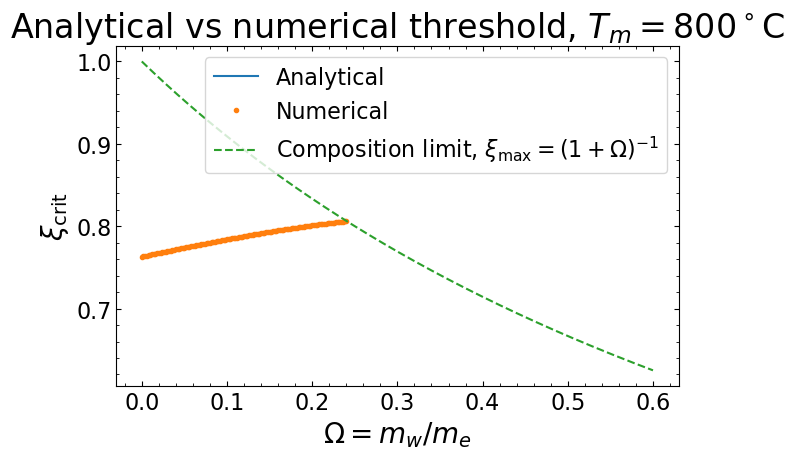

In [115]:
Omega_values = np.linspace(0.0, 0.6, 301)

df_800 = build_comparison_df(
    Tm_C=800.0,
    Omega_values=Omega_values,
)

plot_xi_vs_Omega(df_800, 800.0)

In [121]:
def plot_Ri_vs_Omega(df, Tm_C, logx=False):
    """
    Plot Ri_crit vs Omega:
    analytical = line
    numerical  = markers
    """

    plt.figure(figsize=(7, 5))

    mask_a = np.isfinite(df["Ri_analytical"])
    mask_n = np.isfinite(df["Ri_numerical"])

    plt.plot(
        df.loc[mask_a, "Omega"],
        df.loc[mask_a, "Ri_analytical"],
        label="Analytical",
    )

    plt.plot(
        df.loc[mask_n, "Omega"],
        df.loc[mask_n, "Ri_numerical"],
        linestyle="None",
        marker="o",
        markersize=3,
        label="Numerical",
    )

    if logx:
        plt.xscale("log")

    plt.xlabel(r"$\Omega = m_w/m_e$")
    plt.ylabel(r"$Ri_{\rm crit}$")
    plt.title(rf"Analytical vs numerical $Ri_{{\rm crit}}$, $T_m={Tm_C:.0f}^\circ$C")
    plt.legend()
    plt.tight_layout()
    plt.show()

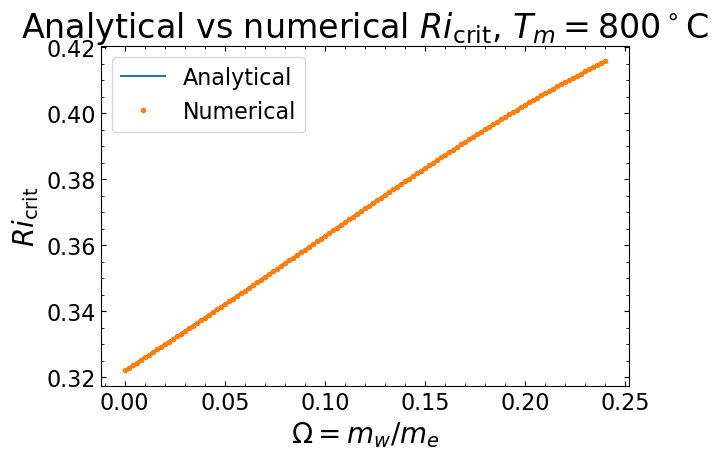

In [125]:
plot_Ri_vs_Omega(df_800, 800.0)

In [127]:
def plot_xi_error(df, Tm_C):
    """
    Plot absolute and relative xi error vs Omega.
    """

    valid = df[np.isfinite(df["abs_error_xi"])].copy()

    plt.figure(figsize=(7, 5))
    plt.plot(valid["Omega"], valid["abs_error_xi"])
    plt.xlabel(r"$\Omega = m_w/m_e$")
    plt.ylabel(r"$|\xi_{\rm num}-\xi_{\rm ana}|$")
    plt.title(rf"Absolute error in $\xi_{{\rm crit}}$, $T_m={Tm_C:.0f}^\circ$C")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(valid["Omega"], valid["rel_error_xi"])
    plt.yscale("log")
    plt.xlabel(r"$\Omega = m_w/m_e$")
    plt.ylabel(r"Relative error")
    plt.title(rf"Relative error in $\xi_{{\rm crit}}$, $T_m={Tm_C:.0f}^\circ$C")
    plt.tight_layout()
    plt.show()

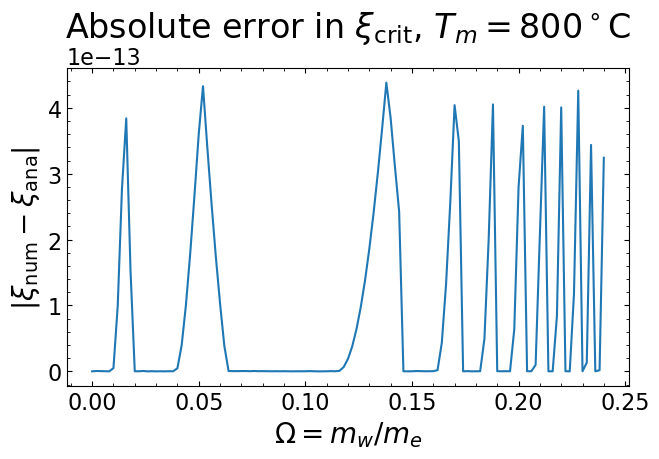

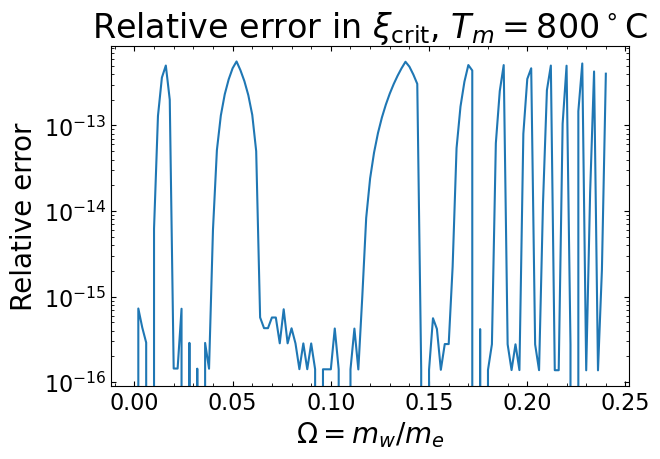

In [129]:
plot_xi_error(df_800, 800.0)

In [131]:
valid = df_800[np.isfinite(df_800["abs_error_xi"])]

print("Max absolute xi error:", valid["abs_error_xi"].max())
print("Max relative xi error:", valid["rel_error_xi"].max())
print("Max |numerical residual|:", valid["residual_numerical"].abs().max())

Max absolute xi error: 4.383160501220118e-13
Max relative xi error: 5.590904514851267e-13
Max |numerical residual|: 9.64500941336155e-08


In [133]:
def plot_multi_temperature_xi(
    Tm_values_C,
    Omega_values,
    base_params=None,
    n_scan=3000,
):
    """
    Overlay analytical curves and numerical markers
    for several magma temperatures.
    """

    plt.figure(figsize=(8, 6))

    for Tm_C in Tm_values_C:

        df = build_comparison_df(
            Tm_C=Tm_C,
            Omega_values=Omega_values,
            base_params=base_params,
            n_scan=n_scan,
        )

        mask_a = np.isfinite(df["xi_analytical"])
        mask_n = np.isfinite(df["xi_numerical"])

        plt.plot(
            df.loc[mask_a, "Omega"],
            df.loc[mask_a, "xi_analytical"],
            label=rf"Analytical, $T_m={Tm_C:.0f}^\circ$C",
        )

        plt.plot(
            df.loc[mask_n, "Omega"],
            df.loc[mask_n, "xi_numerical"],
            linestyle="None",
            marker="o",
            markersize=2.5,
            label=rf"Numerical, $T_m={Tm_C:.0f}^\circ$C",
        )

    xi_max = 1.0 / (1.0 + np.asarray(Omega_values))
    plt.plot(
        Omega_values,
        xi_max,
        linestyle="--",
        label=r"Composition limit",
    )

    plt.xlabel(r"$\Omega = m_w/m_e$")
    plt.ylabel(r"$\xi_{\rm crit}$")
    plt.title("Analytical vs numerical thermodynamic thresholds")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

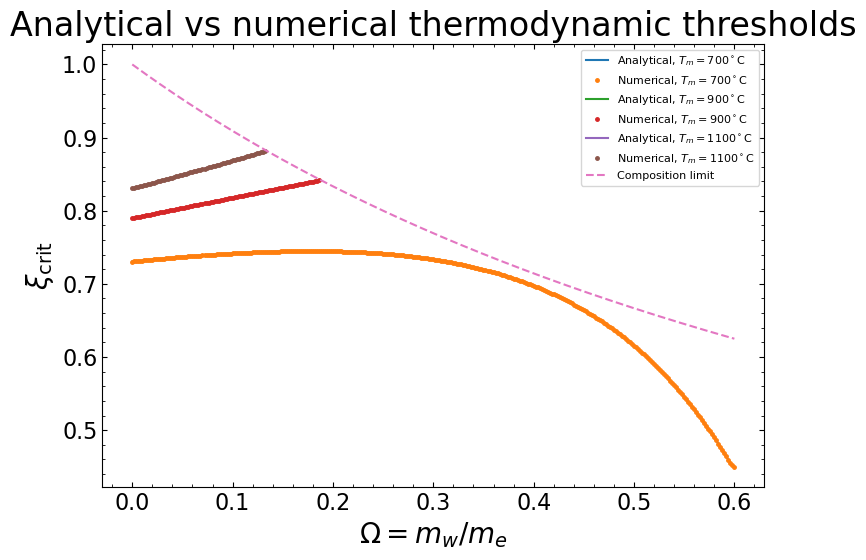

In [135]:
Omega_values = np.linspace(0.0, 0.6, 301)

plot_multi_temperature_xi(
    Tm_values_C=[700.0, 900.0, 1100.0],
    Omega_values=Omega_values,
)

In [145]:
def plot_multi_temperature_Ri_w(
    Tm_values_C,
    Omega_values,
    base_params=None,
    n_scan=3000,
):
    """
    Overlay analytical curves and numerical markers
    for several temperatures in Ri-w space.
    """

    plt.figure(figsize=(8, 6))

    for Tm_C in Tm_values_C:

        df = build_comparison_df(
            Tm_C=Tm_C,
            Omega_values=Omega_values,
            base_params=base_params,
            n_scan=n_scan,
        )

        mask_a = np.isfinite(df["Ri_analytical"])
        mask_n = np.isfinite(df["Ri_numerical"])

        plt.plot(
            df.loc[mask_a, "Ri_analytical"],
            df.loc[mask_a, "w"],
            label=rf"Analytical, $T_m={Tm_C:.0f}^\circ$C",
            linewidth = 4
        )

        plt.plot(
            df.loc[mask_n, "Ri_numerical"],
            df.loc[mask_n, "w"],
            linestyle="None",
            marker="o",
            markersize=1,
            label=rf"Numerical, $T_m={Tm_C:.0f}^\circ$C",
        )

    plt.xscale("log")
    plt.xlabel(r"$Ri_{\rm crit}$")
    plt.ylabel(r"$w = m_w/(m_e+m_w)$")
    plt.title("Analytical vs numerical thermodynamic thresholds in Ri-w space")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

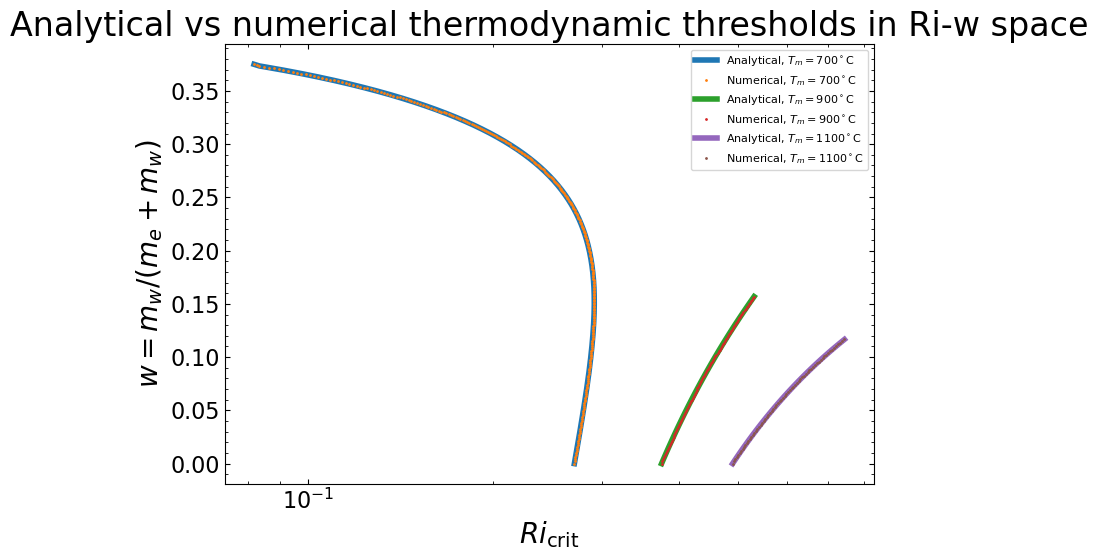

In [147]:
plot_multi_temperature_Ri_w(
    Tm_values_C=[700.0, 900.0, 1100.0],
    Omega_values=Omega_values,
)

In [175]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ============================================================
# BUILD MULTI-TEMPERATURE COMPARISON DATA
# ============================================================

def build_multi_temperature_comparison_df(
    Tm_values_C,
    Omega_values,
    base_params=None,
    n_scan=4000,
):
    """
    Build one dataframe containing analytical and numerical
    threshold solutions for multiple source temperatures.
    """
    if base_params is None:
        base_params = default_params()

    frames = []

    for Tm_C in Tm_values_C:
        df = build_comparison_df(
            Tm_C=Tm_C,
            Omega_values=Omega_values,
            base_params=base_params,
            n_scan=n_scan,
        )
        frames.append(df)

    return pd.concat(frames, ignore_index=True)


# ============================================================
# COMPOSITION-LIMIT CURVES
# ============================================================

def build_limit_curves(Omega_values, base_params=None):
    """
    Build xi_max, Ri_max, and w curves corresponding to the
    mixture-composition limit:
        xi_max = 1 / (1 + Omega)
        w      = Omega / (1 + Omega)
    """
    if base_params is None:
        base_params = default_params()

    rows = []

    for Omega in Omega_values:
        xi_max = 1.0 / (1.0 + Omega)
        w = Omega / (1.0 + Omega)

        # Ri_max diverges at Omega=0 because xi_max=1 there.
        if Omega <= 0.0:
            Ri_max = np.nan
        else:
            p = dict(base_params)
            p["Omega"] = float(Omega)
            Ri_max = Ri_of_xi(xi_max, p)

        rows.append({
            "Omega": Omega,
            "w": w,
            "xi_max": xi_max,
            "Ri_max": Ri_max,
        })

    return pd.DataFrame(rows)


# ============================================================
# FIGURE 3 STYLE:
# left  = xi_crit vs Omega   (x = xi_crit, y = Omega)
# right = Ri_crit vs Omega   (x = Ri_crit, y = Omega)
# ============================================================

def plot_paper_style_fig3_validation(
    Tm_values_C,
    Omega_values,
    base_params=None,
    n_scan=4000,
):
    """
    Recreate the Figure 3 style using the correct axes:
      panel (a): x = xi_crit, y = Omega
      panel (b): x = Ri_crit, y = Omega
    Analytical solutions are lines.
    Numerical solutions are markers.
    """
    if base_params is None:
        base_params = default_params()

    all_df = build_multi_temperature_comparison_df(
        Tm_values_C=Tm_values_C,
        Omega_values=Omega_values,
        base_params=base_params,
        n_scan=n_scan,
    )

    limit_df = build_limit_curves(
        Omega_values=Omega_values,
        base_params=base_params,
    )

    fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))

    ax1, ax2 = axes

    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    colors = {
        Tm_C: color_cycle[i % len(color_cycle)]
        for i, Tm_C in enumerate(Tm_values_C)
    }

    for Tm_C in Tm_values_C:
        df = all_df[all_df["T_m_C"] == Tm_C].copy()
        color = colors[Tm_C]

        # ---------- panel (a): xi_crit vs Omega ----------
        mask_a = np.isfinite(df["xi_analytical"])
        mask_n = np.isfinite(df["xi_numerical"])

        ax1.plot(
            df.loc[mask_a, "xi_analytical"],
            df.loc[mask_a, "Omega"],
            linewidth=1.8,
            color=color,
        )

        ax1.plot(
            df.loc[mask_n, "xi_numerical"],
            df.loc[mask_n, "Omega"],
            linestyle="None",
            marker="o",
            markersize=3.0,
            color=color,
        )

        # ---------- panel (b): Ri_crit vs Omega ----------
        mask_a = np.isfinite(df["Ri_analytical"])
        mask_n = np.isfinite(df["Ri_numerical"])

        ax2.plot(
            df.loc[mask_a, "Ri_analytical"],
            df.loc[mask_a, "Omega"],
            linewidth=1.8,
            color=color,
        )

        ax2.plot(
            df.loc[mask_n, "Ri_numerical"],
            df.loc[mask_n, "Omega"],
            linestyle="None",
            marker="o",
            markersize=3.0,
            color=color,
        )

    # composition / admissibility limit
    ax1.plot(
        limit_df["xi_max"],
        limit_df["Omega"],
        linestyle="--",
        linewidth=1.5,
        color="black",
        label="Mixture composition limit",
    )

    mask_lim = np.isfinite(limit_df["Ri_max"])
    ax2.plot(
        limit_df.loc[mask_lim, "Ri_max"],
        limit_df.loc[mask_lim, "Omega"],
        linestyle="--",
        linewidth=1.5,
        color="black",
        label="Mixture composition limit",
    )

    # axes formatting
    ax1.set_xlabel(r"$\xi_{\rm crit}$")
    ax1.set_ylabel(r"$\Omega = m_w/m_e$")
    ax1.set_title("(a)")
    ax1.set_ylim(min(Omega_values), max(Omega_values))

    ax2.set_xlabel(r"$Ri_{\rm crit}$")
    ax2.set_ylabel(r"$\Omega = m_w/m_e$")
    ax2.set_title("(b)")
    ax2.set_xscale("log")
    ax2.set_ylim(min(Omega_values), max(Omega_values))

    # legend: temperatures + line/marker meaning
    temp_handles = [
        Line2D([0], [0], color=colors[Tm_C], lw=2, label=rf"$T_m={Tm_C:.0f}^\circ$C")
        for Tm_C in Tm_values_C
    ]
    style_handles = [
        Line2D([0], [0], color="black", lw=2, label="Analytical"),
        Line2D([0], [0], color="black", marker="o", linestyle="None", markersize=4, label="Numerical"),
        Line2D([0], [0], color="black", linestyle="--", lw=1.5, label="Composition limit"),
    ]

    ax2.legend(
        handles=temp_handles + style_handles,
        fontsize=8,
        loc="best",
    )

    plt.tight_layout()
    plt.show()

    return all_df, limit_df


# ============================================================
# FIGURE 6 STYLE:
# x = Ri_crit, y = w
# ============================================================

def plot_paper_style_fig6_validation(
    Tm_values_C,
    Omega_values,
    base_params=None,
    n_scan=4000,
):
    """
    Recreate the Figure 6 style using the correct axes:
        x = Ri_crit
        y = w = Omega / (1 + Omega)
    Analytical solutions are lines.
    Numerical solutions are markers.
    """
    if base_params is None:
        base_params = default_params()

    all_df = build_multi_temperature_comparison_df(
        Tm_values_C=Tm_values_C,
        Omega_values=Omega_values,
        base_params=base_params,
        n_scan=n_scan,
    )

    limit_df = build_limit_curves(
        Omega_values=Omega_values,
        base_params=base_params,
    )

    plt.figure(figsize=(8, 6))

    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    colors = {
        Tm_C: color_cycle[i % len(color_cycle)]
        for i, Tm_C in enumerate(Tm_values_C)
    }

    for Tm_C in Tm_values_C:
        df = all_df[all_df["T_m_C"] == Tm_C].copy()
        color = colors[Tm_C]

        mask_a = np.isfinite(df["Ri_analytical"])
        mask_n = np.isfinite(df["Ri_numerical"])

        # analytical = lines
        plt.plot(
            df.loc[mask_a, "Ri_analytical"],
            df.loc[mask_a, "w"],
            linewidth=3,
            color=color,
            alpha = 0.3
        )

        # numerical = markers
        plt.plot(
            df.loc[mask_n, "Ri_numerical"],
            df.loc[mask_n, "w"],
            linestyle="None",
            marker="o",
            markersize=6.0,
            color=color,
        )

    # mixture composition limit
    mask_lim = np.isfinite(limit_df["Ri_max"])
    plt.plot(
        limit_df.loc[mask_lim, "Ri_max"],
        limit_df.loc[mask_lim, "w"],
        linestyle="--",
        linewidth=1.5,
        color="gray",
    )

    plt.xscale("log")
    plt.xlabel(r"$Ri$")
    plt.ylabel(r"$w,\ {\rm external\ water\ mass\ fraction}$")
    plt.title("Analytical vs numerical thermodynamic thresholds")

    temp_handles = [
        Line2D([0], [0], color=colors[Tm_C], lw=2, label=rf"$T_m={Tm_C:.0f}^\circ$C")
        for Tm_C in Tm_values_C
    ]
    style_handles = [
        Line2D([0], [0], color="black", lw=2, label="Analytical", alpha = 0.3),
        Line2D([0], [0], color="black", marker="o", linestyle="None", markersize=4, label="Numerical"),
        Line2D([0], [0], color="gray", linestyle="--", lw=1.5, label="Mixture composition limit"),
    ]

    plt.legend(
        handles=temp_handles + style_handles,
        fontsize=8,
        loc="best",
    )

    plt.tight_layout()
    plt.show()

    return all_df, limit_df

In [177]:
base_params = default_params()
base_params["Y_air_min"] = 0.0

In [207]:
# Omega_values = np.linspace(0.0, 0.6, 301)
# Tm_values_C = [500.0, 700.0, 900.0, 1100.0]

# # Figure 3 style: correct axes are x=xi or Ri, y=Omega
# all_df_fig3, limit_df_fig3 = plot_paper_style_fig3_validation(
#     Tm_values_C=Tm_values_C,
#     Omega_values=Omega_values,
#     base_params=base_params,
#     n_scan=5000,
# )

# # Figure 6 style: correct axes are x=Ri, y=w
# all_df_fig6, limit_df_fig6 = plot_paper_style_fig6_validation(
#     Tm_values_C=Tm_values_C,
#     Omega_values=Omega_values,
#     base_params=base_params,
#     n_scan=5000,
# )

In [181]:
def residual_saturated_vapor(xi, p):
    """
    Counterfactual test:
    all external water is vapor,
    but no superheating is allowed (T = T_sat).
    """

    Omega = p["Omega"]

    omega = Omega * xi
    Y_air = 1.0 - (1.0 + Omega) * xi

    R_mix = (
        xi * p["n"] * p["R_g"]
        + omega * p["R_w"]
        + Y_air * p["R_air"]
    )

    T = p["T_sat"]

    return (
        R_mix * T
        - p["R_air"] * p["T_air"]
    )

In [183]:
from scipy.optimize import brentq
import numpy as np


def xi_crit_saturated_vapor(p, n_scan=3000):

    xi_min = 1e-8
    xi_max = 1.0 / (1.0 + p["Omega"])

    grid = np.linspace(
        xi_min,
        xi_max * (1.0 - 1e-12),
        n_scan
    )

    F = np.array([
        residual_saturated_vapor(xi, p)
        for xi in grid
    ])

    roots = []

    for i in range(len(grid) - 1):

        if F[i] * F[i+1] < 0:

            root = brentq(
                residual_saturated_vapor,
                grid[i],
                grid[i+1],
                args=(p,)
            )

            roots.append(root)

    if len(roots) == 0:
        return np.nan

    # choose closest to dry reference
    xi_dry = xi_crit_dry(p)

    return min(
        roots,
        key=lambda x: abs(x - xi_dry)
    )

In [209]:
p = default_params()

p["T_m"] = 900.0 + 273.15
p["Omega"] = 0.10

# dry
xi_dry = xi_crit_dry(p)

# full Regime C / actual numerical model
out = compute_state_liquid_numerical(p)
xi_full = out["xi_crit"]

# all vapor, but forced to saturation temperature
xi_satvap = xi_crit_saturated_vapor(p)

print("dry               :", xi_dry)
print("saturated vapor   :", xi_satvap)
print("full thermal model:", xi_full)

print()
print("vapor-only shift:",
      xi_satvap - xi_dry)

print("superheat increment:",
      xi_full - xi_satvap)

dry               : 0.7896593210700213
saturated vapor   : 0.3007871166526824
full thermal model: 0.8178434866845853

vapor-only shift: -0.488872204417339
superheat increment: 0.5170563700319029


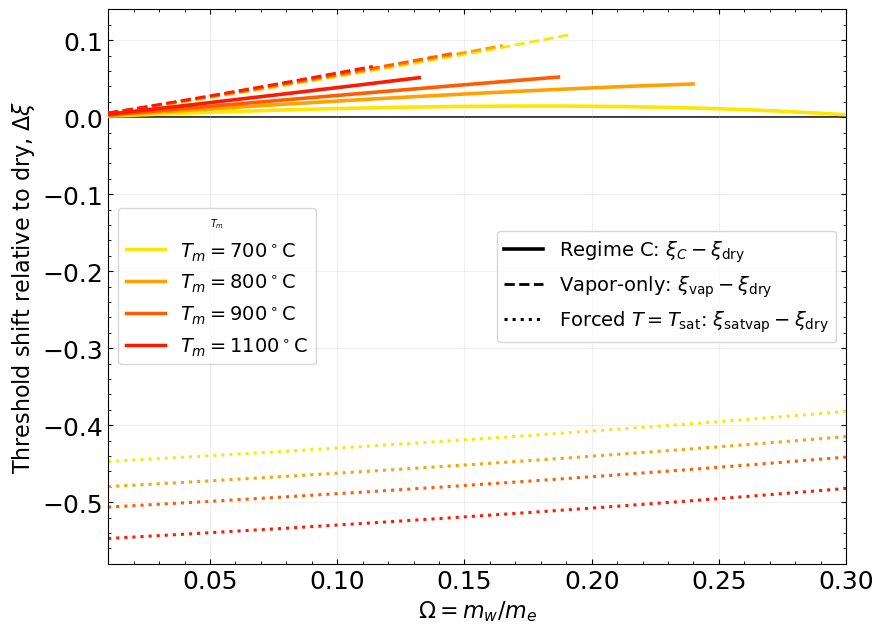

In [238]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ============================================================
# HELPERS
# ============================================================

def _valid_source_loading_root(xi, p):
    """
    Apply the same composition / air-fraction restrictions
    used by the existing Omega-based analytical model.
    """
    if not np.isfinite(xi) or xi <= 1e-12:
        return False

    if not in_bounds_Omega(xi, p):
        return False

    if not valid_air_fraction_Omega(xi, p):
        return False

    return True


# ============================================================
# VAPOR-ONLY MODEL ON THE SAME OMEGA SOURCE-LOADING BASIS
#
# omega_eff = Omega * xi
# Y_air     = 1 - (1 + Omega) * xi
#
# Incoming vapor: T_w = T_sat
# Final mixture T is still determined by sensible-heat mixing.
# ============================================================

def xi_vapor_Omega_analytical(p, T_w=None):

    if T_w is None:
        T_w = p["T_sat"]

    O = p["Omega"]
    R_air = p["R_air"]

    # R_mix = R_air + R1 * xi
    R1 = (
        p["n"] * p["R_g"]
        + O * p["R_w"]
        - (1.0 + O) * R_air
    )

    # Vapor-only sensible-heat mixing:
    #
    # T = (N0 + N1*xi) / (Cp_air + D1*xi)

    N0 = p["Cp_air"] * p["T_air"]

    N1 = (
        p["Cp_m"] * p["T_m"]
        + O * p["Cp_w"] * T_w
        - (1.0 + O) * p["Cp_air"] * p["T_air"]
    )

    D1 = (
        p["Cp_m"]
        + O * p["Cp_w"]
        - (1.0 + O) * p["Cp_air"]
    )

    # Neutral buoyancy leaves:
    #
    # xi * (a*xi + b) = 0

    a = R1 * N1

    b = (
        R_air * N1
        + R1 * N0
        - R_air * p["T_air"] * D1
    )

    if abs(a) < 1e-14:
        return np.nan

    # Nontrivial root
    xi = -b / a

    if not _valid_source_loading_root(xi, p):
        return np.nan

    return xi


# ============================================================
# FORCED FINAL T = T_sat DIAGNOSTIC
#
# Fully vaporized composition,
# but final mixture temperature is artificially fixed at T_sat.
# ============================================================

def xi_satvap_analytical(p):

    O = p["Omega"]

    numerator = (
        p["R_air"]
        * (p["T_sat"] - p["T_air"])
    )

    denominator = (
        p["T_sat"]
        * (
            (1.0 + O) * p["R_air"]
            - p["n"] * p["R_g"]
            - O * p["R_w"]
        )
    )

    if abs(denominator) < 1e-14:
        return np.nan

    xi = numerator / denominator

    if not _valid_source_loading_root(xi, p):
        return np.nan

    return xi


# ============================================================
# SWEEP
# ============================================================

Tm_values_C = [700, 800, 900, 1100]
Omega_values = np.linspace(0.01, 0.30, 160)

rows = []

for Tm_C in Tm_values_C:

    p0 = default_params()
    p0["T_m"] = Tm_C + 273.15

    # Dry threshold for THIS source temperature
    xi_dry = xi_crit_dry(p0)

    previous_xi = None

    for Omega in Omega_values:

        p = dict(p0)
        p["Omega"] = float(Omega)

        # ----------------------------------------------------
        # FULL ANALYTICAL LIQUID-WATER MODEL
        # ----------------------------------------------------

        full = compute_state_liquid_Omega(
            p,
            previous_xi=previous_xi
        )

        xi_full = full["xi_crit"]
        regime_full = full["regime"]

        if np.isfinite(xi_full):
            previous_xi = xi_full

        # We specifically want the physically admissible
        # Regime C threshold for this diagnostic.
        if regime_full == "C":
            xi_C = xi_full
        else:
            xi_C = np.nan

        # ----------------------------------------------------
        # VAPOR-ONLY MODEL
        # Incoming vapor at T_w = T_sat
        # ----------------------------------------------------

        xi_vapor = xi_vapor_Omega_analytical(
            p,
            T_w=p["T_sat"]
        )

        # ----------------------------------------------------
        # FORCED FINAL T = T_sat DIAGNOSTIC
        # ----------------------------------------------------

        xi_satvap = xi_satvap_analytical(p)

        # ----------------------------------------------------
        # SHIFTS RELATIVE TO DRY THRESHOLD
        # ----------------------------------------------------

        delta_C = (
            xi_C - xi_dry
            if np.isfinite(xi_C)
            else np.nan
        )

        delta_vapor = (
            xi_vapor - xi_dry
            if np.isfinite(xi_vapor)
            else np.nan
        )

        delta_satvap = (
            xi_satvap - xi_dry
            if np.isfinite(xi_satvap)
            else np.nan
        )

        rows.append({
            "T_m_C": Tm_C,
            "Omega": Omega,
            "xi_dry": xi_dry,
            "xi_C": xi_C,
            "xi_vapor": xi_vapor,
            "xi_satvap": xi_satvap,
            "regime_full": regime_full,
            "delta_C": delta_C,
            "delta_vapor": delta_vapor,
            "delta_satvap": delta_satvap,
        })


df_compare = pd.DataFrame(rows)


# ============================================================
# FIGURE — ALL SHIFTS RELATIVE TO DRY
# ============================================================

fig, ax = plt.subplots(figsize=(9, 6.5))

colors = plt.cm.autumn_r(
    np.linspace(0.10, 0.90, len(Tm_values_C))
)

for color, Tm_C in zip(colors, Tm_values_C):

    d = (
        df_compare[
            df_compare["T_m_C"] == Tm_C
        ]
        .sort_values("Omega")
    )

    # Full physical Regime C shift relative to dry
    ax.plot(
        d["Omega"],
        d["delta_C"],
        color=color,
        linestyle="-",
        linewidth=2.6,
        zorder=4
    )

    # Vapor-only shift relative to dry
    ax.plot(
        d["Omega"],
        d["delta_vapor"],
        color=color,
        linestyle="--",
        linewidth=2.0,
        zorder=3
    )

    # Forced saturated-vapor diagnostic relative to dry
    ax.plot(
        d["Omega"],
        d["delta_satvap"],
        color=color,
        linestyle=":",
        linewidth=2.2,
        zorder=2
    )


# Dry reference
ax.axhline(
    0.0,
    color="black",
    linewidth=1.1,
    zorder=1
)


# ============================================================
# LEGENDS
# ============================================================

temperature_handles = [
    Line2D(
        [0], [0],
        color=color,
        linewidth=2.5,
        label=rf"$T_m={Tm_C}^\circ$C"
    )
    for color, Tm_C in zip(colors, Tm_values_C)
]

model_handles = [
    Line2D(
        [0], [0],
        color="black",
        linestyle="-",
        linewidth=2.6,
        label=r"Regime C: $\xi_C-\xi_{\rm dry}$"
    ),
    Line2D(
        [0], [0],
        color="black",
        linestyle="--",
        linewidth=2.0,
        label=r"Vapor-only: $\xi_{\rm vap}-\xi_{\rm dry}$"
    ),
    Line2D(
        [0], [0],
        color="black",
        linestyle=":",
        linewidth=2.2,
        label=r"Forced $T=T_{\rm sat}$: "
              r"$\xi_{\rm satvap}-\xi_{\rm dry}$"
    ),
]

leg1 = ax.legend(
    handles=temperature_handles,
    title=r"$T_m$",
    loc="center left",
    frameon=True
)

ax.add_artist(leg1)

ax.legend(
    handles=model_handles,
    loc="center right",
    frameon=True
)


# ============================================================
# FORMATTING
# ============================================================

ax.set_xlabel(
    r"$\Omega=m_w/m_e$",
    fontsize=16
)

ax.set_ylabel(
    r"Threshold shift relative to dry, $\Delta\xi$",
    fontsize=16
)

ax.minorticks_on()
ax.grid(alpha=0.20)

ax.set_xlim(
    Omega_values.min(),
    Omega_values.max()
)

plt.tight_layout()

fig.savefig(
    "xi_dry_reference_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [228]:
params = {
    'legend.title_fontsize' : 'xx-small',
   'axes.labelsize': 16,
   'font.size': 12,
   'legend.fontsize': 14,
   'xtick.labelsize': 18,
   'ytick.labelsize': 18,
   'xtick.direction' : 'in',
   'ytick.direction':'in',
   'xtick.minor.visible' : True,        
   'ytick.minor.visible' : True,
   'xtick.top' : True,
   'ytick.right': True, 
   'figure.autolayout': True   ## get tight layout 
   }
plt.rcParams.update(params)  # update plot paramters
